# Example for fitting JWST spectra

In [1]:
%matplotlib inline
import glob, os, sys, timeit
import matplotlib
import numpy as np
import ipympl

sys.path.append('../')
from pyqsofit.PyQSOFit import QSOFit
from astropy.io import fits
from astropy.table import Table
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

QSOFit.set_mpl_style()

In [2]:
# Show the versions so we know what works
import astropy
import lmfit
import pyqsofit

print(astropy.__version__)
print(lmfit.__version__)
print(pyqsofit.__version__)

import emcee  # optional, for MCMC

print(emcee.__version__)


5.3.4
1.2.2
2.0.0
3.1.4


## Detailed Usage

__Step 1: Set up the model input parameters__<br>
Firstly, run the script below to produce the line list file, qsopar.fits, containing lines and their constraints, which will be needed in the following fitting program. From this file, you can change some specific parameters to suit your requirements, e.g., fitting range, line width, tie line center, tie line sigma, etc. If you want to fit extra lines, please append it to corresponding complex. Note that our line wavelength and sigma in the list are in Ln scale, like Lnlambda, Lnsigma. 

In [3]:
import os.path
import numpy as np
from matplotlib import pyplot as plt
import sys
#sys.path.append("/mnt/ifu/q3dfit-dev_old")
sys.path.append('/Users/weizheliu/q3d_github/q3dfit-dev_230707/')

from copy import copy as copy

sys.path.append("../")
from q3dfit.readcube import Cube


def makeimg(fp,infile,xc=26,yc=27,nradius = 40,wav1=2.89,wav2=2.91,onlydata=False,bincenter=False,sector=False):

    #sp_all = np.array([])
    sp_all = []

    print(os.path.exists(fp+infile+'.fits'),'hahahahahahha')
    #argscube = {'wmapext': None, }#, 'pixarea_sqas': 0.0025, 'fluxnorm': 1}
    argscube = {'wmapext': None, 'pixarea_sqas': 0.0025, 'fluxunit_in': 'MJy/sr', 'fluxnorm': 1e-20, 'fluxunit_out' : 'erg/s/cm2/Angstrom'}
    if onlydata:
        cube = Cube(fp + infile+'.fits', datext=1, varext=-1, dqext=-1, quiet=False,**argscube)
        #cube2 = Cube(fp + infile+'.fits', datext=1, varext=-1, dqext=-1, quiet=False,**argscube)

    else:
        print('6666666666!!!!')
        cube = Cube(fp + infile+'.fits', datext=1, varext=2, dqext=3, quiet=False,**argscube)
        #cube2 = Cube(fp + infile+'.fits', datext=1, varext=2, dqext=3, quiet=False,**argscube)
    dat = cube.dat
    wave = cube.wave
    wid = np.where((wave > wav1) & (wave < wav2))
    img = np.sum(dat[:,:,wid[0]],axis=2)
    x0 = np.arange(cube.ncols)
    y0 = np.arange(cube.nrows)
    X,Y = np.meshgrid(x0,y0)
    rflux = np.zeros(nradius)
    rflux_err = np.zeros(nradius)

    if sector == True:
        # dat_v1 = copy(cube.dat)
        # dat_v1[xc+1:,:,:] = 0
        # dat_v1[:,0:yc,:] = 0
        # cube.dat = dat_v1
        # img = np.sum(dat_v1[:,:,wid[0]],axis=2)

        dat_v1 = copy(cube.dat)
        dat_v1[0:xc-1,:,:] = 0
        dat_v1[:,yc:,:] = 0
        cube.dat = dat_v1
        img = np.sum(dat_v1[:,:,wid[0]],axis=2)

    plt.figure()
    plt.imshow(np.nansum(cube.dat[:,:,wid[0]],axis=2),origin='lower')
    # plt.figure()
    # plt.imshow(np.nansum(cube2.dat[:,:,wid[0]],axis=2),origin='lower')
    plt.show()

    if bincenter == True:
        for i in range(nradius):
            #if i == 0:
            #    rai = 0.01
            #else:
            #    rai = i
            rai = (i+1+1)#*10/nradius  # 20 is for 20 X 0.05'' pixel =  1''  
            sp = cube.specextract(xc,yc,radius=rai,plot=False)
            # plt.figure()
            # plt.plot(wave,sp[:,0])
            # plt.show()


            rf = np.nansum(sp[:,0][wid])
            if i == 0:
                rflux[i] = rf
            else:
                print(np.size(rflux[0:i]))
                #rflux[i] = rf - np.sum(rflux[0:i])
                rflux[i] = rf
                
            rf_var = np.nansum(sp[:,1][wid])
            if i == 0:
                rflux_err[i] = rf_var**0.5
            else:
                #print(np.size(rflux[0:i]))
                #rflux[i] = rf - np.sum(rflux[0:i])
                rflux_err[i] = rf_var**0.5
            pk = np.nansum(cube.dat[xc,yc,wid])
            sp_all.append(sp)
            #sp_all = np.append(sp_all,np.array(sp))


    
    else:    
        for i in range(nradius):
            #if i == 0:
            #    rai = 0.01
            #else:
            #    rai = i
            rai = (i+1)#*10/nradius  # 20 is for 20 X 0.05'' pixel =  1''  
            sp = cube.specextract(xc,yc,radius=rai,plot=False)

            print('jasjdajdsj',np.shape(sp))
            # plt.figure()
            # plt.plot(wave,sp[:,0])
            # plt.show()
            sp_all.append(np.array(sp))
            #sp_all = np.append(sp_all,np.array(sp))


            rf = np.nansum(sp[:,0][wid])
            if i == 0:
                rflux[i] = rf
            else:
                print(np.size(rflux[0:i]))
                #rflux[i] = rf - np.sum(rflux[0:i])
                rflux[i] = rf
                
            rf_var = np.nansum(sp[:,1][wid])
            if i == 0:
                rflux_err[i] = rf_var**0.5
            else:
                #print(np.size(rflux[0:i]))
                #rflux[i] = rf - np.sum(rflux[0:i])
                rflux_err[i] = rf_var**0.5
            pk = np.nansum(cube.dat[xc,yc,wid])
            #if i > 4:    
            #    breakpoint()
    return X,Y,img.T,rflux,rflux_err,pk, wave,sp_all

c = 299792.458
o3wav0 = 5008.24
hbwav0 = 4862.68
def wav2vel(wav,wav0):
    cspeed = 2.99792458e5
    z = (wav/wav0-1)
    vel = ((1+z)**2-1) / ((1+z)**2+1)
    return vel*cspeed
def vel2wav(vel,wav0):
    cspeed = 2.99792458e5
    b = vel/cspeed
    wav = wav0*((1+b)/(1-b))**0.5
    return wav

3.3787477282752625 3.4127309933747143
True hahahahahahha
6666666666!!!!


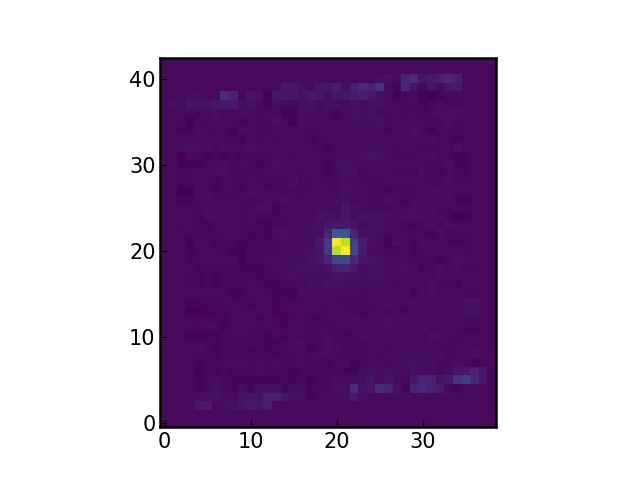

jasjdajdsj (3610, 3)
jasjdajdsj (3610, 3)
1
jasjdajdsj (3610, 3)
2
jasjdajdsj (3610, 3)
3


In [4]:
fp = '/Users/weizheliu/quasar_4_6/final_cubes/'


pdfflag2 = 'J0829+0303'
infile = pdfflag2+'_drizzle_s3d_bkgsub'
dosector = False
pdfflag = 'J0829+0303_v0'
# dosector = True
# pdfflag = 'J0829+0303_sector'
z_sys = 5.855
xcobj = 26
ycobj = 23


pdfflag2 = 'J0840+5624'
infile = pdfflag2+'_drizzle_s3d_bkgsub'
pdfflag = 'J0840+5624_v0'
z_sys = 5.837
xcobj = 22
ycobj = 21


# pdfflag2 = 'J1141+7119'
# infile = pdfflag2+'_drizzle_s3d_bkgsub'
# pdfflag = 'J1141+7119_v0'
# z = 5.851
# xcobj = 27
# ycobj = 27


fitspec= False
nwalkers = 400


nR = 4
z_cor = z_sys




wav1 = vel2wav(-4e3,o3wav0*(1+z_sys)) / 1e4
wav2 = vel2wav(-1e3,o3wav0*(1+z_sys)) / 1e4





from astropy import units as u
from astropy.cosmology import FlatLambdaCDM
cosmo = FlatLambdaCDM(H0=70, Om0=0.3, Tcmb0=2.725)

#dist0 = cosmo.luminosity_distance(z_cor)
kpc_arcsec = cosmo.kpc_proper_per_arcmin(z_cor)/60  


# wav1 = vel2wav(-1500,o3wav0*(1+z)) / 1e4
# wav2 = vel2wav(-300,o3wav0*(1+z)) / 1e4


wavhb1 = vel2wav(-4000,hbwav0*(1+z_sys)) / 1e4
wavhb2 = vel2wav(-2700,hbwav0*(1+z_sys)) / 1e4
print(wav1,wav2)
#X3,Y3, img3, rflux3, pk3 = makeimg(fp,infile,xc=27,yc=27,wav1=3.427,wav2=3.438,nradius=nR,onlydata=True)

#X3,Y3, img3, rflux3,rflux_err3, pk3 = makeimg(fp,infile,xc=xcobj,yc=ycobj,wav1=wav1,wav2=wav2,nradius=nR,onlydata=False)


X3,Y3, img3, rflux3,rflux_err3, pk3, wave3, sp_all3 = makeimg(fp,infile,xc=xcobj,\
                yc=ycobj,wav1=wav1,wav2=wav2,nradius=nR,onlydata=False,bincenter=False,sector=False)


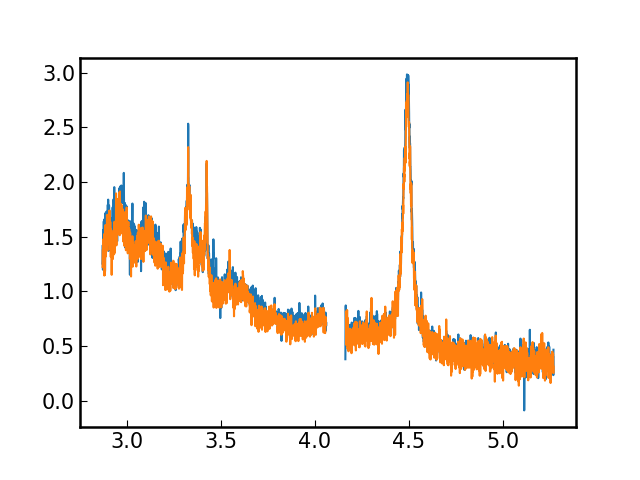

In [5]:
%matplotlib widget
#sp_all3 = sp3
plt.figure()

wavcon1 = 5090*(1+z_sys) / 1e4
wavcon2 = 5115*(1+z_sys) / 1e4


wind = np.where((wave3 > wavcon1) & (wave3 < wavcon2))



kk0 = np.nanmedian((sp_all3[0][:,0])[wind])
kk1 = np.nanmedian((sp_all3[1][:,0]-sp_all3[0][:,0])[wind])
kk2 = np.nanmedian((sp_all3[2][:,0]-sp_all3[1][:,0])[wind])
#kk3 = np.nanmedian((sp_all3[3][:,0]-sp_all3[2][:,0])[wind])

plt.plot(wave3,(sp_all3[0][:,0])/kk0)
plt.plot(wave3,(sp_all3[1][:,0]-sp_all3[0][:,0])/kk1)
#plt.plot(wave3,(sp_all3[2][:,0]-sp_all3[1][:,0])/kk2)
#plt.plot(wave3,(sp_all3[3][:,0]-sp_all3[2][:,0])/kk3)
plt.show()


In [6]:

# create a header
hdr0 = fits.Header()
hdr0['Author'] = ''
primary_hdu = fits.PrimaryHDU(header=hdr0)



path_out = '/Users/weizheliu/quasar_4_6/paper/specfits_2o3_radialbin/'
path_ex = path_out

#%matplotlib notebook

__Step 2: Read the spectrum__ <br>
Setup the paths and read in your spectrum. Our code is written under the frame of SDSS spectral data format. Other data is also available as long as they include wavelength, flux, error, and redshift, and make sure the wavelength resolution is the same as SDSS spectrum (For SDSS the pixel scale is 1.e-4 in log space).

In [7]:

def fnv2fwav(wav,wav0):
    cspeed = 2.99792458e5
    z = (wav/wav0-1)
    fscale = 4*(1+z)/ (2+2*z+z**2)**2
    fscale = wav0/(fscale*cspeed)
    return fscale  #can be multiplied to f_lambda

def readfits(infi,all=False):
    hdu = fits.open(infi)
    #hdu.info()
    #print(hdu[0].header)
    #breakpoint()
    data = hdu[1].data
    #print(data.columns)
    wave = data["wave"]
    flux = data['flux']
    err = data['sig']
    flux_box = data['flux_box']
    err_box = data['sig_box']


    from astropy import units as u
    flux_box0= (flux_box*u.Jy*1e-6).to(u.erg/u.s/u.cm/u.cm/u.AA, u.spectral_density(wave*u.um))
    flux_box = flux_box0.value
    flux0= (flux*u.Jy*1e-6).to(u.erg/u.s/u.cm/u.cm/u.AA, u.spectral_density(wave*u.um))
    flux = flux0.value
    err_box0= (err_box*u.Jy*1e-6).to(u.erg/u.s/u.cm/u.cm/u.AA, u.spectral_density(wave*u.um))
    err_box = err_box0.value
    err0= (err*u.Jy*1e-6).to(u.erg/u.s/u.cm/u.cm/u.AA, u.spectral_density(wave*u.um))
    err = err0.value    
    if all:
    #mask = data['mask']
        return wave,flux,err,flux_box,err_box#,mask
    else:
        return wave,flux,err

In [8]:
# plt.figure()
# plt.plot(lam[s1:s2],(flux-flux_box)[s1:s2])
# #plt.plot(wave2,flux_box)
# plt.ylim(-1,1)

In [9]:
"""
In this table, we specify the priors / initial conditions and boundaries for the line fitting parameters.
"""

line_priors = np.rec.array([
    # (6564.61, 'Ha', 6400, 6800, 'Ha_br', 2, 0.0, 0.0, 1e10, 5e-3, 0.004, 0.05, 0.015, 0, 0, 0, 0.05, 1),
    # (6564.61, 'Ha', 6400, 6800, 'Ha_na', 1, 0.0, 0.0, 1e10, 1e-3, 5e-4, 0.00169, 0.01, 1, 1, 0, 0.002, 1),
    # (6549.85, 'Ha', 6400, 6800, 'NII6549', 1, 0.0, 0.0, 1e10, 1e-3, 2.3e-4, 0.00169, 5e-3, 1, 1, 1, 0.001, 1),
    # (6585.28, 'Ha', 6400, 6800, 'NII6585', 1, 0.0, 0.0, 1e10, 1e-3, 2.3e-4, 0.00169, 5e-3, 1, 1, 1, 0.003, 1),
    # (6718.29, 'Ha', 6400, 6800, 'SII6718', 1, 0.0, 0.0, 1e10, 1e-3, 2.3e-4, 0.00169, 5e-3, 1, 1, 2, 0.001, 1),
    # (6732.67, 'Ha', 6400, 6800, 'SII6732', 1, 0.0, 0.0, 1e10, 1e-3, 2.3e-4, 0.00169, 5e-3, 1, 1, 2, 0.001, 1),

    #(4341.68, 'Hb', 4200, 5100, 'Hg_br', 3, 0.0, 0.0, 1e10, 5e-3, 0.004, 0.01, 0.003, 0, 0, 0, 0.01, 1),

    (4341.68, 'Hb', 4200, 5100, 'Hg_br_1', 1, 0.0, 0.0, 1e10, 5e-3, 2.3e-4, 0.01, 0.005, 5, 5, 0, 0.01, 1),
    (4341.68, 'Hb', 4200, 5100, 'Hg_br_2', 1, 0.0, 0.0, 1e10, 5e-3, 2.3e-4, 0.01, 0.005, 6, 6, 0, 0.01, 1),
    (4341.68, 'Hb', 4200, 5100, 'Hg_br_3', 1, 0.0, 0.0, 1e10, 5e-3, 2.3e-4, 0.01, 0.005, 7, 7, 0, 0.01, 1),
    (4341.68, 'Hb', 4200, 5100, 'Hg_na', 1, 0.0, 0.0, 1e10, 1e-3, 2.3e-4, 0.01, 0.01, 3, 3, 0, 0.002, 1),

    #(4862.68, 'Hb', 4200, 5100, 'Hb_br', 3, 0.0, 0.0, 1e10, 5e-3, 0.004, 0.01, 0.003, 0, 0, 0, 0.01, 1),

    (4862.68, 'Hb', 4200, 5100, 'Hb_br_1', 1, 0.0, 0.0, 1e10, 5e-3, 2.3e-4, 0.01, 0.005, 5, 5, 0, 0.01, 1),
    (4862.68, 'Hb', 4200, 5100, 'Hb_br_2', 1, 0.0, 0.0, 1e10, 5e-3, 2.3e-4, 0.01, 0.005, 6, 6, 0, 0.01, 1),
    (4862.68, 'Hb', 4200, 5100, 'Hb_br_3', 1, 0.0, 0.0, 1e10, 5e-3, 2.3e-4, 0.01, 0.005, 7, 7, 0, 0.01, 1),

    (4862.68, 'Hb', 4200, 5100, 'Hb_na', 1, 0.0, 0.0, 1e10, 1e-3, 2.3e-4, 0.01, 0.01, 3, 3, 0, 0.01, 1),
    
    (4960.30, 'Hb', 4200, 5100, 'OIII4959c', 1, 0.0, 0.0, 1e10, 1e-3, 2.3e-4, 0.01, 0.01, 3, 3, 3, 2, 1),
    (5008.24, 'Hb', 4200, 5100, 'OIII5007c', 1, 0.0, 0.0, 1e10, 1e-3, 2.3e-4, 0.01, 0.01, 3, 3, 3, 2*2.98, 1),
    (4960.30, 'Hb', 4640, 5100, 'OIII4959w',   1, 0.0, 0.0, 1e10, 3e-3, 2.3e-4, 0.01,  0.01,  11, 11, 11, 0.001, 1),
    (5008.24, 'Hb', 4640, 5100, 'OIII5007w',   1, 0.0, 0.0, 1e10, 3e-3, 2.3e-4, 0.01,  0.01,  11, 11, 11, 0.001*2.98, 1),
    #(4960.30, 'Hb', 4640, 5100, 'OIII4959w2',   1, 0.0, 0.0, 1e10, 3e-3, 2.3e-4, 0.01,  0.01,  12, 12, 12, 0.001, 1),
    #(5008.24, 'Hb', 4640, 5100, 'OIII5007w2',   1, 0.0, 0.0, 1e10, 3e-3, 2.3e-4, 0.01,  0.01,  12, 12, 12, 0.001*2.98, 1),
    #(4687.02, 'Hb', 4640, 5100, 'HeII4687_br', 1, 0.0, 0.0, 1e10, 5e-3, 0.004,  0.05,   0.005, 0, 0, 0, 0.001, 1),
    #(4687.02, 'Hb', 4640, 5100, 'HeII4687_na', 1, 0.0, 0.0, 1e10, 1e-3, 2.3e-4, 0.00169, 0.005, 1, 1, 0, 0.001, 1),


    #(1240.14, 'Lya', 1150, 1290, 'NV1240', 1, 0.0, 0.0, 1e10, 2e-3, 0.001, 0.01, 0.005, 0, 0, 0, 0.002, 1),
    # (1215.67, 'Lya', 1150, 1290, 'Lya_na', 1, 0.0, 0.0, 1e10, 1e-3, 5e-4, 0.00169, 0.01, 0, 0, 0, 0.002, 1),
    ],

    formats='float32,    a20,  float32, float32,      a20,  int32, float32, float32, float32, float32, float32, float32, float32,   int32,  int32,  int32, float32, int32',
    names=' lambda, compname,   minwav,  maxwav, linename, ngauss,  inisca,  minsca,  maxsca,  inisig,  minsig,  maxsig,    voff,  vindex, windex, findex,  fvalue,  vary')

# Header
hdr1 = fits.Header()
hdr1['lambda'] = 'Vacuum Wavelength in Ang'
hdr1['minwav'] = 'Lower complex fitting wavelength range'
hdr1['maxwav'] = 'Upper complex fitting wavelength range'
hdr1['ngauss'] = 'Number of Gaussians for the line'

# Can be set to negative for absorption lines if you want
hdr1['inisca'] = 'Initial guess of line scale [flux]'
hdr1['minsca'] = 'Lower range of line scale [flux]'
hdr1['maxsca'] = 'Upper range of line scale [flux]'

hdr1['inisig'] = 'Initial guess of linesigma [lnlambda]'
hdr1['minsig'] = 'Lower range of line sigma [lnlambda]'
hdr1['maxsig'] = 'Upper range of line sigma [lnlambda]'

hdr1['voff  '] = 'Limits on velocity offset from the central wavelength [lnlambda]'
hdr1['vindex'] = 'Entries w/ same NONZERO vindex constrained to have same velocity'
hdr1['windex'] = 'Entries w/ same NONZERO windex constrained to have same width'
hdr1['findex'] = 'Entries w/ same NONZERO findex have constrained flux ratios'
hdr1['fvalue'] = 'Relative scale factor for entries w/ same findex'

hdr1['vary'] = 'Whether or not to vary the parameter (set to 0 to fix the line parameter to initial values)'

# Save line info
hdu1 = fits.BinTableHDU(data=line_priors, header=hdr1, name='line_priors')

In [10]:
np.log(5000) - np.log(4950), 50/5000*3e5

(0.0100503358535029, 3000.0)

In [11]:
5540*7

38780

In [12]:
"""
In this table, we specify the windows and priors / initial conditions and boundaries for the continuum fitting parameters.
"""

conti_windows = np.rec.array([
    (1150., 1170.), 
    (1275., 1290.),
    (1350., 1360.),
    (1445., 1465.),
    (1690., 1705.),
    (1770., 1810.),
    (1970., 2400.),
    (2480., 2675.),
    (2925., 3400.),
    (3775., 3832.),
    (4000., 4050.),
    (4200., 4230.),
    (4435., 4670.),
    (5100., 5535.),
    (6005., 6035.),
    (6110., 6250.),
    (6800., 7000.),
    (7160., 7180.),
    (7500., 7800.),
    (8050., 8150.), # Continuum fitting windows (to avoid emission line, etc.)  [AA]
    ], 
    formats = 'float32,  float32',
    names =    'min,     max')

hdu2 = fits.BinTableHDU(data=conti_windows, name='conti_windows')

conti_priors = np.rec.array([
    ('Fe_uv_norm',  0.0,   0.0,   1e10,  1), # Normalization of the MgII Fe template [flux]
    ('Fe_uv_FWHM',  3000,  1200,  18000, 1), # FWHM of the MgII Fe template [AA]
    ('Fe_uv_shift', 0.0,   -0.01, 0.01,  1), # Wavelength shift of the MgII Fe template [lnlambda]
    ('Fe_op_norm',  0.0,   0.0,   1e10,  1), # Normalization of the Hbeta/Halpha Fe template [flux]
    #('Fe_op_FWHM',  3000,  1200,  18000, 1), # FWHM of the Hbeta/Halpha Fe template [AA]
    ('Fe_op_FWHM',  3000,  1200,  18000, 1), # FWHM of the Hbeta/Halpha Fe template [AA]
    ('Fe_op_shift', 0.0,   -0.01, 0.01,  1), # Wavelength shift of the Hbeta/Halpha Fe template [lnlambda]
    ('PL_norm',     1.0,   0.0,   1e10,  1), # Normalization of the power-law (PL) continuum f_lambda = (lambda/3000)^-alpha
    ('PL_slope',    -1.5,  -5.0,  3.0,   1), # Slope of the power-law (PL) continuum
    ('Blamer_norm', 0.0,   0.0,   1e10,  1), # Normalization of the Balmer continuum at < 3646 AA [flux] (Dietrich et al. 2002)
    ('Balmer_Te',   15000, 10000, 50000, 1), # Te of the Balmer continuum at < 3646 AA [K?]
    ('Balmer_Tau',  0.5,   0.1,   2.0,   1), # Tau of the Balmer continuum at < 3646 AA
    ('conti_a_0',   0.0,   None,  None,  1), # 1st coefficient of the polynomial continuum
    ('conti_a_1',   0.0,   None,  None,  1), # 2nd coefficient of the polynomial continuum
    ('conti_a_2',   0.0,   None,  None,  1), # 3rd coefficient of the polynomial continuum
    # Note: The min/max bounds on the conti_a_0 coefficients are ignored by the code,
    # so they can be determined automatically for numerical stability.
    ],

    formats = 'a20,  float32, float32, float32, int32',
    names = 'parname, initial,   min,     max,     vary')

hdr3 = fits.Header()
hdr3['ini'] = 'Initial guess of line scale [flux]'
hdr3['min'] = 'FWHM of the MgII Fe template'
hdr3['max'] = 'Wavelength shift of the MgII Fe template'

hdr3['vary'] = 'Whether or not to vary the parameter (set to 0 to fix the continuum parameter to initial values)'


hdu3 = fits.BinTableHDU(data=conti_priors, header=hdr3, name='conti_priors')

In [13]:
"""
In this table, we allow user to customized some key parameters in our result measurements.
"""

measure_info = Table(
    [
        [[1350, 1450, 3000, 4200, 5100]],
        [[
            # [2240, 2650], 
            [4435, 4685],
        ]]
    ],
    names=([
        'cont_loc',
        'Fe_flux_range'
    ]),
    dtype=([
        'float32',
        'float32'
    ])
)
hdr4 = fits.Header()
hdr4['cont_loc'] = 'The wavelength of continuum luminosity in results'
hdr4['Fe_flux_range'] = 'Fe emission wavelength range calculated in results'

hdu4 = fits.BinTableHDU(data=measure_info, header=hdr4, name='measure_info')

#hdu_list = fits.HDUList([primary_hdu, hdu1, hdu2, hdu3, hdu4])
#hdu_list.writeto(os.path.join(path_out, 'qsopar.fits'), overwrite=True)

In [14]:
path_out

'/Users/weizheliu/quasar_4_6/paper/specfits_2o3_radialbin/'

__Print the table:__

In [15]:
Table(line_priors)

lambda,compname,minwav,maxwav,linename,ngauss,inisca,minsca,maxsca,inisig,minsig,maxsig,voff,vindex,windex,findex,fvalue,vary
float32,bytes20,float32,float32,bytes20,int32,float32,float32,float32,float32,float32,float32,float32,int32,int32,int32,float32,int32
4341.68,Hb,4200.0,5100.0,Hg_br_1,1,0.0,0.0,10000000000.0,0.005,0.00023,0.01,0.005,5,5,0,0.01,1
4341.68,Hb,4200.0,5100.0,Hg_br_2,1,0.0,0.0,10000000000.0,0.005,0.00023,0.01,0.005,6,6,0,0.01,1
4341.68,Hb,4200.0,5100.0,Hg_br_3,1,0.0,0.0,10000000000.0,0.005,0.00023,0.01,0.005,7,7,0,0.01,1
4341.68,Hb,4200.0,5100.0,Hg_na,1,0.0,0.0,10000000000.0,0.001,0.00023,0.01,0.01,3,3,0,0.002,1
4862.68,Hb,4200.0,5100.0,Hb_br_1,1,0.0,0.0,10000000000.0,0.005,0.00023,0.01,0.005,5,5,0,0.01,1
4862.68,Hb,4200.0,5100.0,Hb_br_2,1,0.0,0.0,10000000000.0,0.005,0.00023,0.01,0.005,6,6,0,0.01,1
4862.68,Hb,4200.0,5100.0,Hb_br_3,1,0.0,0.0,10000000000.0,0.005,0.00023,0.01,0.005,7,7,0,0.01,1
4862.68,Hb,4200.0,5100.0,Hb_na,1,0.0,0.0,10000000000.0,0.001,0.00023,0.01,0.01,3,3,0,0.01,1
4960.3,Hb,4200.0,5100.0,OIII4959c,1,0.0,0.0,10000000000.0,0.001,0.00023,0.01,0.01,3,3,3,2.0,1


In [16]:
np.log(5008)-  np.log(4990)

0.0036007240343689517

In [17]:
(4990-5008)/5008*3e5

-1078.2747603833866

Note: if you want to tie the line properties in different complex, you can enlarge the complex range.

In [18]:
path_ex,path_out

('/Users/weizheliu/quasar_4_6/paper/specfits_2o3_radialbin/',
 '/Users/weizheliu/quasar_4_6/paper/specfits_2o3_radialbin/')

In [19]:
directory = '/Users/weizheliu/quasar_4_6/final_cubes/'
files = os.listdir(directory)
#txt_files = [file for file in files if '_1d.txt' in file]


# import os
# directory = '/Users/weizheliu/quasar_4_6/final_cubes/'
# import glob
# import sys
# sys.path.append('/Users/weizheliu/q3d_github/q3dfit-dev_230707/')


# # List all files in the directory

# # Filter files containing 'fits' in their names
fits_files_3d = [file for file in files if '_s3d_bkgsub.fits' in file]

# #print(fits_files_2d)
namelist = []
# spec1dfile = []
# waveall = []
# fluxall = []
# varall = []
txt_files = []

# from q3dfit.q3din import q3din

for infile in (fits_files_3d):
    #label=np.append(label,infile[0:10])
    label = infile[0:10]
    namelist = np.append(namelist,label)
#     print(directory+infile)
#     q3di = q3din(directory+infile, label, datext=1, varext=2, dqext=3)
#     #q3di.argsreadcube = {'wmapext': None, 'pixarea_sqas': 0.0025, 'fluxnorm': 1e-20, 'fluxunit_in' : 'erg/s/cm2/A'}
#     #q3di.argsreadcube = {'wmapext': None, 'pixarea_sqas': 1, 'fluxnorm': 1e-20, 'fluxunit_out' : 'erg/s/cm2/A', 'fluxunit_in' : 'erg/s/cm2/A'}
#     q3di.argsreadcube = {'wmapext': None, 'pixarea_sqas': 0.01, 'fluxnorm': 1e4, 'fluxunit_out' : 'erg/s/cm2/A'}
#     q3di.__dict__
#     cube = q3di.load_cube()
#     data = cube.dat
#     w1 = 2500
#     w2 = 3400
#     print(np.shape(data))
#     map2d = np.nansum(data,axis=2)
#     xc,yc = np.where(map2d == np.nanmax(map2d))
#     print(xc,yc)
#     spec_test = cube.specextract(xc[0]+1,yc[0]+1,radius=3)
#     # spec_test2 = cube.specextract(27., 26., radius=2)
#     # spec_test3 = cube.specextract(27., 26., radius=5)
#     spec1dfile = np.append(spec1dfile,directory+label+'1d.fits')
#     #waveall = np.append(waveall,cube.wave)
#     #fluxall = np.append(fluxall,spec_test[:,0])
#     #varall = np.append(varall,spec_test[:,1])
#     # create HDUList
#     #hh_l = fits.HDUList([hh1])
#     #hhl_append(fits.Table)
#     # add data
#     #np.savetxt(directory+label+'_1d.txt',np.array([cube.wave,spec_test[:,0],spec_test[:,1]]).T)
    txt_files = np.append(txt_files,directory+label+'_1d.txt')
    # plt.figure()
    # plt.plot(lam,flux)
#     #cube.writespec(spec_test,directory+label+'1d.txt')
# #errall = varall**0.5

In [20]:
namelist

array(['J1620+5202', 'J0759+1800', 'J1328+4445', 'J0807+1328',
       'J0829+0303', 'J1100+5800', 'J1050+4627', 'J0840+5624',
       'J1327+5732', 'J1141+7119', 'J0859+2520'], dtype='<U32')

In [21]:
c = 299792.458

def wav2vel(wav,wav0):
    cspeed = 2.99792458e5
    z = (wav/wav0-1)
    vel = ((1+z)**2-1) / ((1+z)**2+1)
    return vel*cspeed
def vel2wav(vel,wav0):
    cspeed = 2.99792458e5
    b = vel/cspeed
    wav = wav0*((1+b)/(1-b))**0.5
    return wav

def z2vel(z):
    cspeed = 2.99792458e5
    vel = ((1+z)**2-1) / ((1+z)**2+1)
    return vel*cspeed


def vel2z(vel):
    cspeed = 2.99792458e5
    b = vel/cspeed
    z = ((1+b)/(1-b))**0.5-1
    return z


def fwav2fvel(wav,wav0):
    cspeed = 2.99792458e5
    z = (wav/wav0-1)
    fscale = 4*(1+z)/ (2+2*z+z**2)**2
    fscale = wav0/(fscale*cspeed)
    return fscale  #can be multiplied to f_lambda

In [22]:
sys.path.append('/Users/weizheliu/cos-ulirg/pycos')
from nonparam_short import *

__Step 3: Fit the spectrum__<br>
Use QSOFit to input the lam, flux, err, z, and other optinal parameters. Use function Fit to perform the fitting. Default settings cannot meet all needs. Please change settings for your own requirements. It depends on what science you need. The following example set dereddening, host decomposition to True.

The ``broad_fwhm`` parameter can be adjusted depending on your definition (default is 1200 km s$^{-1}$).



In [23]:
# Filter files containing 'fits' in their names
#fits_files = [file for file in files if '_spec1d_coadd.fits' in file]
# #fwhm_res = header['fwhm']

# fwhm_res = 25
# print(fwhm_res)
# #ebv = header['ebv']
# ebv = 0

# # from UV
# redshift = np.loadtxt('/Users/weizheliu/quasar_4_6/observed_targets_keyinfo',unpack=True,usecols=(1))
# namelist,redshift






In [24]:
bad = 0
v98_all = []
v50_all = []
v90_all = []
v10_all = []
w80_all = []

mcmc_all = []

name_bad2 = []

kk = 0
doFe = True
Fe_uv_op = True
dopoly = False
niter = 4e3
niter = 1e3
jjall = np.arange(np.size(txt_files))
wave_mask = None
#nwalkers = 2000

# for file,targname,z,jj in zip(txt_files,namelist,redshift,jjall):  
#     if targname != 'J0859+2520':
#         continue



# for file,targname,z,jj in zip(txt_files,namelist,redshift,jjall):  
#     if targname != 'J0859+2520':
#         continue


targname = pdfflag2 #_raidalbin'
z = z_sys

if fitspec:
    for i in range(nR):  

        # if i < 3:
        continue
        spp = sp_all3[i]

        nameflag = targname+'_raidalbin'+str(int(i))

        # old one
        scale = 1
        
        waveobs = wave3
        flux_opt = spp[:,0]
        err_opt = spp[:,1]**0.5
        #flux_opt,err_opt= np.loadtxt(file,unpack=True)


        lam = waveobs * 1e4
        flux = flux_opt*scale
        err= err_opt*scale
        q_mle = QSOFit(lam, flux, err, z, path=path_ex)


        hdu_list = fits.HDUList([primary_hdu, hdu1, hdu2, hdu3, hdu4])
        hdu_list.writeto(os.path.join(path_out, nameflag+'qsopar.fits'), overwrite=True)
        #print(file,z)
        
        # if 'J1458+3327' in targname or 'J0807' in targname:
        #    continue
        # #niter=1e3
        #nwalkers = 400
        

        # if targname in ['J1050+4627','J1328+4445','J1327+5732','J1050+4627']:#,'J1141+7119','J0859+2520']:
        #     Fe_uv_op = False
        #     #continue
        # else:
        #     Fe_uv_op = True
        # #     continue
        
        # if targname == 'J1141+7119':
        #     nwalkers = 800




        #wave_range = [4200,5450] # default
        # fit is bad for J0759+1800 if include the blueside of the detector gap
        if z < 5:
            #wave_mask = np.array([[np.min([2.35e4/(1+z),4100]),2.50e4/(1+z)]])
            #wave_mask = np.array([[2.35e4/(1+z),2.48e4/(1+z)]])
            wave_range = [3999,5450]
            if z > (2.35e4/4025-1):# and targname != 'J0759+1800':   
                wave_mask = np.array([[2.39e4/(1+z),2.52e4/(1+z)]])
                wave_range = [3770,5450]
            else:
                wave_mask = np.array([[2.35e4/(1+z),2.48e4/(1+z)]])
        if z > 5:
            wave_range = [4200,5540]
        print(wave_mask)
        # if  z < 5:
        #     wave_range = [3000,5450]
        # if z < 0:
        #     z = 6.71 # two targets no z


        

        plt.figure()
        plt.plot(lam,flux)
        
        plt.show()
        # continue


        #try:
        if True:
            print(wave_range)
            q_mle.Fit(name=nameflag,  # customize the name of given targets. Default: plate-mjd-fiber
                    # prepocessing parameters
                    nsmooth=1,  # do n-pixel smoothing to the raw input flux and err spectra
                    and_mask=False,  # delete the and masked pixels
                    or_mask=False,  # delete the or masked pixels
                    reject_badpix=True,  # reject 10 most possible outliers by the test of pointDistGESD
                    deredden=True,  # correct the Galactic extinction
                    wave_range=wave_range,  # trim input wavelength
                    wave_mask=wave_mask,  # 2-D array, mask the given range(s)    
                    # host decomposition parameters
                    decompose_host=False,  # If True, the host galaxy-QSO decomposition will be applied
                    host_prior=True, # If True, the code will adopt prior-informed method to assist decomposition. Currently, only 'CZBIN1' and 'DZBIN1' model for QSO PCA are available. And the model for galaxy must be PCA too.
                    host_prior_scale=0.2, # scale of prior panelty. Usually, 0.2 works fine for SDSS spectra. Adjust it smaller if you find the prior affect the fitting results too much.
            
                    host_line_mask=True, # If True, the line region of galaxy will be masked when subtracted from original spectra.
                    decomp_na_mask=True, # If True, the narrow line region will be masked when perform decomposition
                    qso_type='CZBIN1', # PCA template name for quasar
                    npca_qso=10, # numebr of quasar templates
                    host_type='PCA', # template name for galaxy
                    npca_gal=5, # number of galaxy templates
                    
                    # continuum model fit parameters
                    Fe_uv_op=Fe_uv_op,  # If True, fit continuum with UV and optical FeII template
                    poly=dopoly,  # If True, fit continuum with the polynomial component to account for the dust reddening
                    BC=False,  # If True, fit continuum with Balmer continua from 1000 to 3646A
                    initial_guess=None,  # Initial parameters for continuum model, read the annotation of this function for detail
                    rej_abs_conti=False,  # If True, it will iterately reject 3 sigma outlier absorption pixels in the continuum
                    n_pix_min_conti=100,  # Minimum number of negative pixels for host continuuum fit to be rejected.
            
                    # emission line fit parameters
                    linefit=True,  # If True, the emission line will be fitted
                    rej_abs_line=False,
                    # If True, it will iterately reject 3 sigma outlier absorption pixels in the emission lines
            
                    # fitting method selection
                    #MC=True,
                    MC=False,
                    # If True, do Monte Carlo resampling of the spectrum based on the input error array to produce the MC error array
                    MCMC=True,
        
                    epsilon_jitter=0, nburn=400, nsamp=int(niter), nthin=400,
                    # advanced fitting parameters
                    param_file_name=path_out+nameflag+'qsopar.fits',  # Name of the qso fitting parameter FITS file.
                    #nburn=20,  # The number of burn-in samples to run MCMC chain
                    #nthin=10,  # To set the MCMC chain returns every n samples
                    #epsilon_jitter=0.,
                    # Initial jitter for every initial guass to avoid local minimum. (Under test, not recommanded to change)
            
                    # customize the results
                    save_result=True,  # If True, all the fitting results will be saved to a fits file
                    save_fits_name=None,  # The output name of the result fits
                    save_fits_path=path_out,  # The output path of the result fits
                    plot_fig=True,  # If True, the fitting results will be plotted
                    save_fig=True,  # If True, the figure will be saved
                    plot_corner=False,  # Whether or not to plot the corner plot results if MCMC=True
            
                    # debugging mode
                    verbose=True,  # turn on (True) or off (False) debugging output
            
                    # sublevel parameters for figure plot and emcee
                    kwargs_plot={
                        'save_fig_path': path_out,  # The output path of the figure
                        'broad_fwhm'   : 1200  # km/s, lower limit that code decide if a line component belongs to broad component
                    },
                    kwargs_conti_emcee={},
                    kwargs_line_emcee={"nwalkers":nwalkers})

        

        
        # print(f'Fitting finished in {np.round(end - start, 1)}s')
        file_path = nameflag+"mcmcfit_results.pkl"

        # Open the file in binary write mode
        with open(file_path, 'wb') as f:
        # Serialize and save the object to the file
            pickle.dump(q_mle, f)

        # try:
        #     v98,v50,v90,v10,w80 = postanalysis(q_mle)
        #     v98_all = np.append(v98_all,v98) 
        #     v50_all = np.append(v50_all,v50) 
        #     v90_all = np.append(v90_all,v90) 
        #     v10_all = np.append(v10_all,v10) 
        #     w80_all = np.append(w80_all,w80) 
        #     mcmc_all = np.append(mcmc_all,q_mle)
        # except:
        #     None



3.3787477282752625 3.4127309933747143
True hahahahahahha
6666666666!!!!


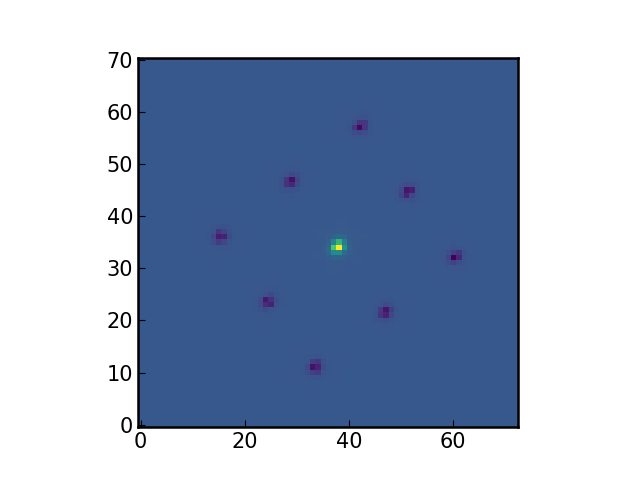

jasjdajdsj (3610, 3)
jasjdajdsj (3610, 3)
1
jasjdajdsj (3610, 3)
2
jasjdajdsj (3610, 3)
3


In [25]:
#fp4 = '/mnt/ifu/quasar_4_6/'


fp4 = '/Users/weizheliu/quasar_4_6/JWST_IFU_star_TYC4433-1800-1/MAST_2024-11-07T21_34_00.231Z/JWST/'

infile4 = 'jw01128-o009_t007_nirspec_g395h-f290lp_s3d'
print(wav1,wav2)
#if 0:
X_g395,Y_g395, img_g395, rflux_g395, g395_err, pk_g395, wave_g395, sp_all_395 = makeimg(fp4,infile4,xc=35,yc=39,\
                                                                 wav1=wav1,wav2=wav2,nradius=nR,onlydata=False,sector=False)

# X_g395_2,Y_g395_2, img_g395_2, rflux_g395_2, g395_err_2, pk_g395_2 = \
#     makeimg(fp4,infile4,xc=35,yc=39,wav1=wav1,wav2=wav2,nradius=nR,onlydata=False,bincenter=True)


    #X_g395,Y_g395, img_g395, rflux_g395, pk_g395 = makeimg(fp4,infile4,xc=35,yc=39,wav1=3.427,wav2=3.438,nradius=nR,onlydata=False)
    #X2,Y2, img2, rflux2, pk2 = makeimg(fp,infile,xc=35,yc=39,nradius=nR,onlydata=True)

In [26]:

def get_err(s, margin=0.16, axis=0, default_value=-1.):
    """
    Get 100*margin percent distribution of a given data.
    :param s: 1-D array or 2-D array. If a 1-D array is given, the data will deem the array as the data sample and the
    axis parameter will be ignored. If a 2-D array is given, how the function deel with this data will depend on the
    axis. If axis==0, the function will calculate the distribution of each column of the array. If axis==1, the
    function will calculate the distribution of each row of the array.
    :param margin: The margin of the distribution. The default value is 16%, which means the function will calculate
    about 1 sigma error for each sample
    :param axis: How the function deel with the data, see above.
    :return: float or 1-D array, depends on the input data.
    """
    s = np.array(s)
    s[s == default_value] = np.nan
    margin_per = int(margin * 100)
    if s.ndim == 1:
        N_samp = len(s)
        if np.sum(np.isnan(s)) / N_samp > 0.5:
            return default_value
        else:
            # if self.verbose:
            #     print('Warning: The input data contains more than 50% nan values. The error would be set to -1.')
            return np.diff(np.nanpercentile(s, (margin_per, 100 - margin_per)))[0] / 2
    elif s.ndim == 2:
        if axis == 1:
            s = s.T
        if not axis in [0, 1]:
            raise IndexError('The axis parameter only adopts 0 or 1.')
        N_samp = s.shape[0]
        Na_idx = np.where(np.sum(np.isnan(s), axis=0) > N_samp / 2, True, False)
        data_err = np.diff(np.nanpercentile(s, (margin_per, 100 - margin_per), axis=0), axis=0)[0] / 2
        data_err[Na_idx] = default_value
        return data_err
    else:
        raise IndexError('The input data only adopts 1-D or 2-D array.')

In [27]:


def update_err(gauss_result_name, gauss_result_all):

    # the output from pyqsofit does not give err to all tied parameters, 
    # assign the correct values to them again.


    # all wavelength in log scale, gaussian of log(x) is still gaussian if x is gaussian  
    gauss_result_name = gauss_result_name[1::2]
    from copy import copy as copy
    gauss_result_all_new = copy(gauss_result_all)
    nsample = np.shape(gauss_result_all)[0]
    npar = np.size(gauss_result_name)
    #gauss_result_all_new = np.zeros((nsample,npar))
    #for i in range(nsample):

    cid2 = np.where(gauss_result_name == 'Hg_br_3_1_centerwave_err')[0]    
    cid = np.where(gauss_result_name == 'Hb_br_3_1_centerwave_err')[0]


    
    if np.size(cid2) >0:
        print(np.shape(gauss_result_all_new[:,cid]))
        print(np.shape(gauss_result_all[:,cid2]))


        gauss_result_all_new[:,cid] = gauss_result_all[:,cid2] + np.log(hbwav0)-np.log(hgwav0)
    
    cid2 = np.where(gauss_result_name == 'Hg_br_3_1_sigma_err')[0]   
    cid = np.where(gauss_result_name == 'Hb_br_3_1_sigma_err')[0]
    if np.size(cid2) >0 and np.size(cid) >0:
        gauss_result_all_new[:,cid] = gauss_result_all[:,cid2]

    
    
    cid2 = np.where(gauss_result_name == 'Hg_br_2_1_centerwave_err')[0]    
    cid = np.where(gauss_result_name == 'Hb_br_2_1_centerwave_err')[0]
    if np.size(cid2) >0 and np.size(cid) >0:
        gauss_result_all_new[:,cid] = gauss_result_all[:,cid2] + np.log(hbwav0)-np.log(hgwav0)
    cid2 = np.where(gauss_result_name == 'Hg_br_2_1_sigma_err')[0] 
    cid = np.where(gauss_result_name == 'Hb_br_2_1_sigma_err')[0]
    if np.size(cid2) >0 and np.size(cid) >0:
        gauss_result_all_new[:,cid] = gauss_result_all[:,cid2]

    
    
    cid2 = np.where(gauss_result_name == 'Hg_br_1_1_centerwave_err')[0]    
    cid = np.where(gauss_result_name == 'Hb_br_1_1_centerwave_err')[0]
    if np.size(cid2) >0 and np.size(cid) >0:
        gauss_result_all_new[:,cid] = gauss_result_all[:,cid2] + np.log(hbwav0)-np.log(hgwav0)
    cid2 = np.where(gauss_result_name == 'Hg_br_1_1_sigma_err')[0] 
    cid = np.where(gauss_result_name == 'Hb_br_1_1_sigma_err')[0]
    if np.size(cid2) >0 and np.size(cid) >0:
        gauss_result_all_new[:,cid] = gauss_result_all[:,cid2]

    

        

    # gauss_result_all_new[:,cid] = gauss_result_all[:,cid2] + np.log(hbwav0)-np.log(hgwav0)
    cid2 = np.where(gauss_result_name == 'Hg_na_1_1_centerwave_err')[0]   
    cid = np.where(gauss_result_name == 'Hb_na_1_centerwave_err')[0]
    if np.size(cid2) >0 and np.size(cid) >0:
        gauss_result_all_new[:,cid] = gauss_result_all[:,cid2] + np.log(hbwav0)-np.log(hgwav0)
    
    
    cid2 = np.where(gauss_result_name == 'Hg_na_1_1_sigma_err')[0]   
    cid = np.where(gauss_result_name == 'Hb_na_1_sigma_err')[0]
    if np.size(cid2) >0 and np.size(cid) >0:
        gauss_result_all_new[:,cid] = gauss_result_all[:,cid2] + np.log(hbwav0)-np.log(hgwav0)


    
    # narrow O3
    temp_id = np.where(gauss_result_name == 'OIII4959c_1_centerwave_err')[0]
    print('temp_id:',temp_id)
    print(np.shape(gauss_result_all[:,temp_id]))
    if gauss_result_all[:,temp_id][0] == 0:
        cid2 = np.where(gauss_result_name == 'Hg_na_1_1_sigma_err')[0]   
        cid = np.where(gauss_result_name == 'Hb_na_1_sigma_err')[0]
        print('cid2:',cid2)
        #print('cid2:',cid2[0])
        print('shape:',np.shape(gauss_result_name))
        if np.size(cid2) >0 and np.size(cid) >0:
            cid3 = np.where(gauss_result_name == 'OIII4959c_1_centerwave_err')[0]
            cid4 = np.where(gauss_result_name == 'OIII5007c_1_centerwave_err')[0]
            if np.size(cid3) >0:
                #gauss_result_all_new[:,cid] = gauss_result_all[:,cid2] + np.log(hbwav0)-np.log(hgwav0)
                gauss_result_all_new[:,cid3] = gauss_result_all[:,cid2]+ np.log(o31wav0)-np.log(hgwav0)
                gauss_result_all_new[:,cid4] = gauss_result_all[:,cid2]+ np.log(o32wav0)-np.log(hgwav0)
        cid2 = np.where(gauss_result_name == 'Hg_na_1_1_sigma_err')[0]   
        cid = np.where(gauss_result_name == 'Hb_na_1_sigma_err')[0]
        if np.size(cid2) >0 and np.size(cid) >0:
            cid3 = np.where(gauss_result_name == 'OIII4959c_1_sigma_err')[0]
            cid4 = np.where(gauss_result_name == 'OIII5007c_1_sigma_err')[0]
            if np.size(cid3) >0:
                #gauss_result_all_new[:,cid] = gauss_result_all[:,cid2] + np.log(hbwav0)-np.log(hgwav0)
                gauss_result_all_new[:,cid3] = gauss_result_all[:,cid2]+ np.log(o31wav0)-np.log(hgwav0)
                gauss_result_all_new[:,cid4] = gauss_result_all[:,cid2]+ np.log(o32wav0)-np.log(hgwav0)           
    else:
        print('!!!@#!@#!@#!#!@#!@#!')
        cid3 = np.where(gauss_result_name == 'OIII4959c_1_centerwave_err')[0]
        cid4 = np.where(gauss_result_name == 'OIII5007c_1_centerwave_err')[0]
        if np.size(cid3) >0:
            gauss_result_all_new[:,cid4] = gauss_result_all[:,cid3]+ np.log(o32wav0)-np.log(o31wav0)
        cid3 = np.where(gauss_result_name == 'OIII4959c_1_sigma_err')[0]
        cid4 = np.where(gauss_result_name == 'OIII5007c_1_sigma_err')[0]
        if np.size(cid3) >0:
            #gauss_result_all_new[:,cid] = gauss_result_all[:,cid2] + np.log(hbwav0)-np.log(hgwav0)
            gauss_result_all_new[:,cid4] = gauss_result_all[:,cid3]+ np.log(o32wav0)-np.log(o31wav0)               
    # broad O3

    cid2 = np.where(gauss_result_name == 'OIII4959w_1_centerwave_err')[0]
    cid = np.where(gauss_result_name == 'OIII5007w_1_centerwave_err')[0]
    if np.size(cid2) >0 and np.size(cid) >0:
        gauss_result_all_new[:,cid] = gauss_result_all[:,cid2] + np.log(o32wav0)-np.log(o31wav0)

    cid2 = np.where(gauss_result_name == 'OIII4959w_1_sigma_err')[0]
    cid = np.where(gauss_result_name == 'OIII5007w_1_sigma_err')[0]
    if np.size(cid2) >0 and np.size(cid) >0:
        gauss_result_all_new[:,cid] = gauss_result_all[:,cid2] + np.log(o32wav0)-np.log(o31wav0)

        
 

    #     print(a,b)  
    return gauss_result_all_new


In [28]:
def postanalysis(q_mcmc,nameflag,usehbredshift = False,fullwave=False,\
                 dofurresult=False, domcmcerr=True, flip_o3wave=False):


    #wave_5007_standard = np.linspace(0,1e4,1e3)
    wave_5007_standard = np.linspace(4300, 5150, 500)
    #from nonparam_2025 import NonParam
    try: 
    #if 1:
        if fullwave:
            gauss_result = (q_mcmc.gauss_result[3:])
            gauss_result_err = (q_mcmc.gauss_result[3:])*0.05
        else:
            if q_mcmc.MCMC:
                gauss_result = q_mcmc.gauss_result[::2]
                gauss_result_err = q_mcmc.gauss_result[1::2]
            else:
                gauss_result = q_mcmc.gauss_result
    except:
        return q_mcmc,np.nan,np.nan, np.nan,np.nan,np.nan,np.nan,np.nan,np.nan,np.nan,np.nan,np.nan,np.nan,\
        np.nan,np.nan,np.nan,np.nan,np.nan,np.nan,np.nan,np.nan,np.nan,np.nan,\
        np.nan,np.nan,np.nan,np.nan,np.nan,np.nan,np.nan,np.nan,np.nan,np.nan,\
        np.nan, np.nan

    samples = q_mcmc.gauss_result_all
    # Plot individual line components
    

    all_broad = 0
    all_hb = 0
    all_o3 = 0 # only 5007!!!!!
    all_doub_o3 = 0
    all_o3_up = 0
    all_o3_down = 0
    all_o3_4959 = 0

    # correct redshift to the narrow comp of O3 or Hb if possible

    o3nnid = np.where(q_mcmc.gauss_result_name == 'OIII5007c_1_centerwave')
    o3nnid2 = np.where(q_mcmc.gauss_result_name == 'OIII5007w_1_centerwave')
    o3nnid_sig = np.where(q_mcmc.gauss_result_name == 'OIII5007c_1_sigma')
    o3nnid2_sig = np.where(q_mcmc.gauss_result_name == 'OIII5007w_1_sigma')
    o3nnid_scale = np.where(q_mcmc.gauss_result_name == 'OIII5007c_1_sigma')
    o3nnid2_scale = np.where(q_mcmc.gauss_result_name == 'OIII5007w_1_sigma')



    
    if np.size(o3nnid2) < 1:
        o3nnid2 = o3nnid  # temporary
    if np.size(o3nnid) > 0 and usehbredshift == False:
        zcorflag = 'o3'
        bestfitwavo31 = np.exp(q_mcmc.gauss_result[o3nnid])
        bestfitwavo32 = np.exp(q_mcmc.gauss_result[o3nnid2])
        bestfitsigo31 = (q_mcmc.gauss_result[o3nnid_sig])
        bestfitsigo32 = (q_mcmc.gauss_result[o3nnid2_sig])
        bestfitscaleo31 = (q_mcmc.gauss_result[o3nnid_scale])
        bestfitscaleo32 = (q_mcmc.gauss_result[o3nnid2_scale])
        print(bestfitsigo31,bestfitsigo32)
        if flip_o3wave:
            if (bestfitsigo31 > bestfitsigo32):
                bestfitwavo3 = bestfitwavo32
                print('flipped!!!!!!!!!!')
            else:
                bestfitwavo3 = bestfitwavo31
        else:
            bestfitwavo3 = bestfitwavo31
        dwav_o3 = bestfitwavo3 -  o3wav0
        #z_o3n = 
        #q_mcmc.gauss_result[::2]
        q_mcmc.wave_cor = q_mcmc.wave - dwav_o3
    else:

        zcorflag = 'hb'
        for p in range(int(len(gauss_result) / 3)):
            if 'Hb' in q_mcmc.gauss_result_name[::2][3 * p]:
                all_hb = all_hb + q_mcmc.Onegauss(np.log(q_mcmc.wave), gauss_result[p * 3:(p + 1) * 3])

        hbpeakid = np.argmax(all_hb)
        bestfitwavhb = q_mcmc.wave[hbpeakid]
        dwav_hb = bestfitwavhb -  hbwav0
        q_mcmc.wave_cor = q_mcmc.wave - dwav_hb
        bestfitwavo3 = bestfitwavhb



    if np.size(o3nnid) == 0: # and np.size(o3nnid2) == 0:
        return q_mcmc, np.nan,np.nan,np.nan,np.nan,np.nan,np.nan,np.nan,np.nan,np.nan,np.nan,np.nan,np.nan,\
        np.nan,np.nan,np.nan,np.nan,np.nan,np.nan,np.nan,np.nan,np.nan,np.nan,\
        np.nan,np.nan,np.nan,np.nan,np.nan,np.nan,np.nan,np.nan,np.nan,np.nan,\
        np.nan, np.nan


    o3vel = wav2vel(q_mcmc.wave_cor,o3wav0)
    o34959vel = wav2vel(q_mcmc.wave_cor,o34959wav0)
    hbvel = wav2vel(q_mcmc.wave_cor,hbwav0)

    
    for p in range(int(len(gauss_result) / 3)):
        if 'Hb' in q_mcmc.gauss_result_name[::2][3 * p]:
            if q_mcmc.CalFWHM(gauss_result[3 * p + 2]) < 1200:  # < 1200 km/s narrow
                color = 'g'  # narrow
            else:
                color = 'r'  # broad
                all_broad = all_broad +q_mcmc.Onegauss(np.log(q_mcmc.wave), gauss_result[p * 3:(p + 1) * 3])
            all_hb = all_hb + q_mcmc.Onegauss(np.log(q_mcmc.wave), gauss_result[p * 3:(p + 1) * 3])
        if 'OIII5007' in q_mcmc.gauss_result_name[::2][3 * p]:
            if q_mcmc.CalFWHM(gauss_result[3 * p + 2]) < 1200:  # < 1200 km/s narrow
                color = 'g'  # narrow
            else:
                color = 'r'  # broad
            all_o3 = all_o3 + q_mcmc.Onegauss(np.log(q_mcmc.wave), gauss_result[p * 3:(p + 1) * 3])

        if 'OIII4959' in q_mcmc.gauss_result_name[::2][3 * p]:
            if q_mcmc.CalFWHM(gauss_result[3 * p + 2]) < 1200:  # < 1200 km/s narrow
                color = 'g'  # narrow
            else:
                color = 'r'  # broad
            all_o3_4959 = all_o3_4959 + q_mcmc.Onegauss(np.log(q_mcmc.wave), gauss_result[p * 3:(p + 1) * 3])

        if 'OIII' in q_mcmc.gauss_result_name[::2][3 * p]:
            if q_mcmc.CalFWHM(gauss_result[3 * p + 2]) < 1200:  # < 1200 km/s narrow
                color = 'g'  # narrow
            else:
                color = 'r'  # broad
                #all_broad = all_broad +q_mcmc.Onegauss(np.log(q_mcmc.wave), gauss_result[p * 3:(p + 1) * 3])
            color = 'b'
            all_doub_o3 = all_doub_o3 + q_mcmc.Onegauss(np.log(q_mcmc.wave), gauss_result[p * 3:(p + 1) * 3])

        # Plot total line model

    flux_noHb = q_mcmc.line_flux - all_hb
    flux_Hb = q_mcmc.line_flux - all_doub_o3 
    flux_o35007 = all_o3 #flux_noHb - (all_doub_o3 - all_o3)
    flux_o34959 = flux_noHb - all_o3

    all_o3_interp = interpolate_spectrum(q_mcmc.wave_cor,all_o3,wave_5007_standard)
    q_mcmc.o35007prof = all_o3_interp
    q_mcmc.wave_5007_standard = wave_5007_standard


    
    try:
        wave = q_mcmc.wave_cor
        #wave = q_mcmc.wave  >???????? why use this ?????
            
        o3flux = all_o3  # for line 5007 only
        o3flux_err = q_mcmc.err    # use the original flux err, which overestimates the error for O3
        o3flux_err22 = q_mcmc.err*all_o3/q_mcmc.flux  

        fo3_tot = np.nansum(o3flux)
        fo3_tot_err = (np.nansum(o3flux_err**2))**0.5

        vlow =  -4e3
        fo3_1500 = np.nansum(o3flux[ (o3vel < -1.5e3) & (o3vel > vlow) ])
        fo3_1500_err = (np.nansum(o3flux_err[ (o3vel < -1.5e3) & (o3vel > -1e4) ]**2))**0.5

        fo3_1000 = np.nansum(o3flux[ (o3vel < -1.0e3) & (o3vel > vlow) ])
        fo3_1000_err = (np.nansum(o3flux_err[ (o3vel < -1.0e3) & (o3vel > vlow) ]**2))**0.5
        fo3_1000_err22 = (np.nansum(o3flux_err22[ (o3vel < -1.0e3) & (o3vel > vlow) ]**2))**0.5

        fo3_500 = np.nansum(o3flux[ (o3vel < -5e2) & (o3vel > vlow)  ])
        fo3_500_err = (np.nansum(o3flux_err[ (o3vel < -5e2) & (o3vel > vlow) ]**2))**0.5

        o3nonpar = NonParam(wave,o3flux,o3flux_err,wave0=o3wav0,useraw=False)
        a02 = o3nonpar.v(vthres = 0.02, eps=1e-3, plot=False)
        a05 = o3nonpar.v(vthres = 0.05, eps=1e-1, plot=False)
        a95 = o3nonpar.v(vthres = 0.95, eps=1e-1, plot=False)
        a10 = o3nonpar.v(vthres = 0.1, eps=1e-1, plot=False)
        a90 = o3nonpar.v(vthres = 0.9, eps=1e-1, plot=False)
        a50 = o3nonpar.v(vthres = 0.5, eps=1e-1, plot=False)

    except Exception as e:
       # Print the error message
       print(f"An error occurred: {e}")

    #if 1:
    try:
        #print('hahahhaha',a02)
        v98 = a02[0]
        v98_err0 = a02[1]
        # v98_err1 = a02up[0] - v98
        # v98_err2 = a02down[0] - v98
    except:
        v98 = np.nan
        v98_err0 = np.nan
        v98_err1 = np.nan
        v98_err2 = np.nan
    try:
        v05 = a05[0]
        v05_err0 = a05[1]
        # v05_err1 = a05up[0] - v05
        # v05_err2 = a05down[0] - v05
    except:
        v05 = np.nan
        v05_err0 = np.nan
        # v05_err1 = np.nan
        # v05_err2 = np.nan
    try:
        v95 = a95[0]
        v95_err0 = a95[1]
        # v95_err1 = a95up[0] - v95
        # v95_err2 = a95down[0] - v95
    except:
        v95 = np.nan
        v95_err0 = np.nan
        # v95_err1 = np.nan
        # v95_err2 = np.nan
    try:
        v90 = a90[0]
        v90_err0 = a90[1]
        # v90_err1 = a90up[0] - v90
        # v90_err2 = a90down[0] - v90
    except:
        v90 = np.nan
        v90_err0 = np.nan
        # v90_err1 = np.nan
        # v90_err2 = np.nan
    try:
        v50 = a50[0]
        v50_err0 = a50[1]
        # v50_err1 = a50up[0] - v50
        # v50_err2 = a50down[0] - v50
    except:
        v50 = np.nan
        v50_err0 = np.nan
        # v50_err1 = np.nan
        # v50_err2 = np.nan
    try:
        v10 = a10[0]
        v10_err0 = a10[1]
        # v10_err1 = a10up[0] - v10
        # v10_err2 = a10down[0] - v10
    except:
        v10 = np.nan
        v10_err0 = np.nan
        # v10_err1 = np.nan
        # v10_err2 = np.nan
        
    w90 = v95-v05
    w80 = v90 - v10
    w90_err0 = (v95_err0**2+v05_err0**2)**0.5
    w80_err0 = (v90_err0**2+v10_err0**2)**0.5



    ###############
    # # calculate error from the MCMC samples
    ###############

    if domcmcerr:

        cind1 = -9
        cind2 = -6
        cind3 = -3
        cind4 = 0
        print(q_mcmc.gauss_result_name[::2][-9],q_mcmc.gauss_result_name[::2][-6]\
              ,q_mcmc.gauss_result_name[::2][-3],q_mcmc.gauss_result_name[::2][-1])
        if 1:
            #assign err to those tied parameters without values
            samples_new = update_err(q_mcmc.gauss_result_name, q_mcmc.gauss_result_all)
        else:
            samples_new = q_mcmc.gauss_result_all


        # 100 samples of parameter values from the MCMC
        print(np.shape(samples_new),np.shape(q_mcmc.gauss_result_all))
        samples_0 = samples_new[:, np.r_[cind1:cind2, cind3:cind4]]

        fur_result_temp = np.zeros([8, np.shape(samples_0)[0]])
        fur_result_flux_temp = np.zeros([1, np.shape(samples_0)[0]])


        for k, pp in enumerate(samples_0):
            #fur_result_temp[:,k] = calnonpar(q_mcmc, pp)  

            all_o3_tmp = 0
            for p in range(int(len(pp) / 3)):
                print('ppppppppppp',pp)
                print(np.shape(samples_new),np.shape(samples_0),np.shape(q_mcmc.gauss_result),np.shape(pp))
                all_o3_tmp = all_o3_tmp + q_mcmc.Onegauss(np.log(q_mcmc.wave), pp[p * 3:(p + 1) * 3])   


            print(np.shape(fur_result_flux_temp), np.shape(all_o3_tmp))
            print(all_o3_tmp)
            #fur_result_flux_temp[:,k] = (np.nansum(all_o3_tmp))
            fur_result_flux_temp[:,k] = (np.nansum(all_o3_tmp[ (o3vel < -1e3) & (o3vel > -8e3) ]))

        fo3_1000_mcmc_err = get_err(fur_result_flux_temp, axis=1)
        #fo3_1000_err = o3_1000_mcmc_err


        print('fo3_1000_errrrrrr:',fo3_1000_err)
        #return fur_result_temp
        # fur_result_std_1s = get_err(fur_result_temp, axis=1)
        # if 
        # fur_result_std_1s = get_err(fur_result_temp, axis=1)
        # v98_err_1s = fur_result_std_1s[0]
        # v05_err_1s = fur_result_std_1s[1]
        # v95_err_1s = fur_result_std_1s[2]
        # v50_err_1s = fur_result_std_1s[3]
        # v10_err_1s = fur_result_std_1s[4]
        # v90_err_1s = fur_result_std_1s[5]
        # w80_err_1s = fur_result_std_1s[6]
        # w90_err_1s = fur_result_std_1s[7]

        # fur_result_std = get_err(fur_result_temp, axis=1,margin=0.025)
        # v98_err = fur_result_std[0]
        # v05_err = fur_result_std[1]
        # v95_err = fur_result_std[2]
        # v50_err = fur_result_std[3]
        # v10_err = fur_result_std[4]
        # v90_err = fur_result_std[5]
        # w80_err = fur_result_std[6]
        # w90_err = fur_result_std[7]
    

    #else:
        v98_err = 0
        v05_err = 0
        v95_err = 0
        v50_err = 0
        v10_err = 0
        v90_err = 0
        w80_err = 0
        w90_err = 0    
        v98_err_1s = 0
        v95_err_1s = 0
        v05_err_1s = 0
        v50_err_1s = 0
        v10_err_1s = 0
        v90_err_1s = 0
        w80_err_1s = 0
        w90_err_1s = 0
        

    '''
    ###
    Even the margin=0.025 seem to suggest lower error than the err from function nonpar errors
    ###
    '''
    if dofurresult:
        return fur_result_temp,q_mcmc,fo3_tot,fo3_tot_err, v98,v50,v90,v10,v05,v95,w80,w90, v98_err,v50_err,v90_err,v10_err,v05_err,v95_err,w80_err,w90_err,\
v98_err_1s,v50_err_1s,v90_err_1s,v10_err_1s,v05_err_1s,v95_err_1s,w80_err_1s,w90_err_1s,\
v98_err0,v50_err0,v90_err0,v10_err0,w80_err0,w90_err0, bestfitwavo3,zcorflag
    else:
        return q_mcmc,fo3_tot,fo3_tot_err,fo3_1500,fo3_1500_err,fo3_1000,fo3_1000_err,fo3_1000_err22,fo3_1000_mcmc_err,fo3_500,fo3_500_err, v98,v50,v90,v10,v05,v95,w80,w90, v98_err,v50_err,v90_err,v10_err,v05_err,v95_err,w80_err,w90_err,\
v98_err_1s,v50_err_1s,v90_err_1s,v10_err_1s,v05_err_1s,v95_err_1s,w80_err_1s,w90_err_1s,\
v98_err0,v50_err0,v90_err0,v10_err0,w80_err0,w90_err0, bestfitwavo3,zcorflag
    

In [29]:
import numpy as np
from scipy.interpolate import interp1d


from spectres import spectres

def interpolate_spectrum(wave, flux, new_wave, uncert=None, method='linear'):
    """
    Interpolate spectrum to a common wavelength grid.



    Returns:
    -------
    new_flux : array
        Flux interpolated to the new wavelength grid.
    new_uncert : array, optional
        Interpolated uncertainties (returned only if `uncert` is provided).
    """
    # Interpolate the flux
    new_flux = spectres(new_wave, wave, flux)#, kind=method, bounds_error=False, fill_value=np.nan)
    #new_flux = flux_interp(new_wave)

    
    return new_flux


def boxcar_smooth(flux, window_size):
    """
    Smooth a spectrum using a moving average (boxcar) method.

    Parameters:
    ----------
    flux : array-like
        The flux values to smooth.
    window_size : int
        The size of the moving window (must be odd for symmetric smoothing).

    Returns:
    -------
    smoothed_flux : array
        Smoothed flux values.
    """
    if window_size % 2 == 0:
        raise ValueError("Window size must be odd.")
    return np.convolve(flux, np.ones(window_size)/window_size, mode='same')



In [30]:
global o3wav0, o34959wav0, hbwav0, hgwav0, cs 
o3wav0 = 5008.24	
o34959wav0 = 4960.295	
hbwav0 = 4862.68
cs = 2.99792458e5
hgwav0 = 4341.68
o31wav0 = o34959wav0
o32wav0 = o3wav0




In [31]:
fo3_tot_all = []
fo3b_all = []
fo3_1500_all = []
fo3_1500_err_all = []
fo3_1000_all = []
fo3_1000_err_all = []
fo3_1000_err22_all = []
fo3_1000_err_mcmc_all = []

fo3_500_all = []
fo3_500_err_all = []

L5100_all = []  
L5100_err_all = []  
L4200_all = []
L4200_err_all = []
L5000_all = []
L5000_err_all = []
domcmcerr = True
usehbredshift = True

#redshift = 4.779
for i in range(nR):  
    spp = sp_all3[i]
    nameflag = targname+'_raidalbin'+str(int(i))
    file_path = nameflag+"mcmcfit_results.pkl"
    with open(file_path, 'rb') as f:
        # Deserialize the object from the file
        print(f)
        q_mcmc = pickle.load(f)
    q_mcmc,fo3_tot, fo3_tot_err,fo3_1500,fo3_1500_err, fo3_1000,fo3_1000_err,fo3_1000_err22,fo3_1000_mcmc_err,fo3_500,fo3_500_err, v98,v50,v90,v10,v05,v95,w80,w90, v98_err,v50_err,v90_err,v10_err,v05_err,v95_err,w80_err,w90_err,\
        v98_err_1s,v50_err_1s,v90_err_1s,v10_err_1s,v05_err_1s,v95_err_1s,w80_err_1s,w90_err_1s,\
    v98_err0,v50_err0,v90_err0,v10_err0,w80_err0,w90_err0, besto3nw,zcorflag_t = \
        postanalysis(q_mcmc,targname,domcmcerr=domcmcerr,usehbredshift=usehbredshift,flip_o3wave=False)
    o3broad_par = [q_mcmc.gauss_result[q_mcmc.gauss_result_name == 'OIII5007w_1_scale'],\
                    q_mcmc.gauss_result[q_mcmc.gauss_result_name == 'OIII5007w_1_centerwave'],\
                    q_mcmc.gauss_result[q_mcmc.gauss_result_name == 'OIII5007w_1_sigma']]

    spec_o3b = q_mcmc.Onegauss(np.log(q_mcmc.wave), o3broad_par)
    fo3_b = np.nansum(spec_o3b)

    L5100 = float(q_mcmc.conti_result[-4])-20 #- np.log10(scale) + np.log10(aper_cor)
    L4200 = float(q_mcmc.conti_result[-6])-20 #- np.log10(scale) + np.log10(aper_cor)
    L5100_err = float(q_mcmc.conti_result[-3])-20 #- np.log10(scale) + np.log10(aper_cor)
    L4200_err = float(q_mcmc.conti_result[-5])-20 #- np.log10(scale) + np.log10(aper_cor)

    alpha = float(q_mcmc.conti_result[q_mcmc.conti_result_name == 'PL_slope'][0])
    L5000 = 10**L5100 * (5000/5100)**(alpha)  # assuming alpha=-1.5 

    L5100_all.append(10**L5100)
    L4200_all.append(10**(L4200)) 
    L5000_all.append((L5000)) 



    fo3_tot_all.append(fo3_tot) 

    fo3_500_all.append(fo3_500)   
    fo3_500_err_all.append(fo3_500_err)
    fo3_1000_all.append(fo3_1000)   
    fo3_1000_err_all.append(fo3_1000_err)
    fo3_1000_err22_all.append(fo3_1000_err22)
    fo3_1000_err_mcmc_all.append(fo3_1000_mcmc_err)


    fo3_1500_all.append(fo3_1500)   
    fo3_1500_err_all.append(fo3_1500_err)

    fo3b_all.append(fo3_b)

fo3_1500_all = np.array(fo3_1500_all)
fo3_1500_err_all = np.array(fo3_1500_err_all)

fo3_1000_err_all = np.array(fo3_1000_err_all)
fo3_1000_err22_all = np.array(fo3_1000_err22_all)
fo3_1000_err_mcmc_all = np.array(fo3_1000_err_mcmc_all)



fo3b_all = np.array(fo3b_all)
fo3_tot_all = np.array(fo3_tot_all)
L5100_all = np.array(L5100_all)

<_io.BufferedReader name='J0840+5624_raidalbin0mcmcfit_results.pkl'>
114464.0626746307  ?????
114464.0626746307  ?????
!!!!!!
116868.35645691305  ?????
116868.35645691305  ?????
!!!!!!
132202.64499398277  !!!!
!!!!!!
118980.87924345498  !!!!
!!!!!!
130117.97522502087  ?????
130117.97522502087  ?????
!!!!!!
124995.92905583384  ?????
124995.92905583384  ?????
!!!!!!
OIII5007c_1_scale OIII4959w_1_scale OIII5007w_1_scale OIII5007w_1_sigma
(400, 1)
(400, 1)
temp_id: [25]
(400, 1)
!!!@#!@#!@#!#!@#!@#!
(400, 36) (400, 36)
ppppppppppp [1.99010161e+02 8.51873600e+00 1.04663891e-02 4.81664131e+01
 8.51789807e+00 1.96128274e-02]
(400, 36) (400, 6) (72,) (6,)
ppppppppppp [1.99010161e+02 8.51873600e+00 1.04663891e-02 4.81664131e+01
 8.51789807e+00 1.96128274e-02]
(400, 36) (400, 6) (72,) (6,)
(1, 400) (1378,)
[2.46285476e-16 2.73630271e-16 3.03951982e-16 ... 7.53235752e-05
 7.19132538e-05 6.86523939e-05]
ppppppppppp [1.99010161e+02 8.51873600e+00 1.04663891e-02 4.81664131e+01
 8.51797975e+00 1.9535

In [32]:
q_mcmc.conti_result_name

array(['ra', 'dec', 'plateid', 'MJD', 'fiberid', 'redshift',
       'SN_ratio_conti', 'Fe_uv_norm', 'Fe_uv_norm_err', 'Fe_uv_FWHM',
       'Fe_uv_FWHM_err', 'Fe_uv_shift', 'Fe_uv_shift_err', 'Fe_op_norm',
       'Fe_op_norm_err', 'Fe_op_FWHM', 'Fe_op_FWHM_err', 'Fe_op_shift',
       'Fe_op_shift_err', 'PL_norm', 'PL_norm_err', 'PL_slope',
       'PL_slope_err', 'Blamer_norm', 'Blamer_norm_err', 'Balmer_Te',
       'Balmer_Te_err', 'Balmer_Tau', 'Balmer_Tau_err', 'conti_a_0',
       'conti_a_0_err', 'conti_a_1', 'conti_a_1_err', 'conti_a_2',
       'conti_a_2_err', 'L1350', 'L1350_err', 'L1450', 'L1450_err',
       'L3000', 'L3000_err', 'L4200', 'L4200_err', 'L5100', 'L5100_err',
       'Fe_flux_4435_4685', 'Fe_flux_4435_4685_err'], dtype='<U32')

In [33]:
fo3b_all, fo3_1500_all, fo3_1000_all/np.array(fo3_1000_err_all)

(array([ 6212.90208466, 14364.1303394 , 15526.74907507, 18066.53883711]),
 array([1391.67303363, 5057.85328543, 4035.42474123, 5085.44741225]),
 array([24.25199513, 49.58432942, 34.44777198, 32.17237492]))

In [34]:
L5000_all / L5100_all

array([1.05453512, 1.05388088, 1.05298818, 1.0518446 ])

In [35]:
fo3b_all
fo3_1500_all

array([1391.67303363, 5057.85328543, 4035.42474123, 5085.44741225])

In [36]:
# #fp4 = '/mnt/ifu/quasar_4_6/'

# fp4 = '/Users/weizheliu/quasar_4_6/JWST_IFU_star_TYC4433-1800-1/MAST_2024-11-07T21_34_00.231Z/JWST/'

# infile4 = 'jw01128-o009_t007_nirspec_g395h-f290lp_s3d'
# print(wav1,wav2)
# #if 0:
# X_g395,Y_g395, img_g395, rflux_g395, g395_err, pk_g395, wave_g395, sp_all_395 = makeimg(fp4,infile4,xc=35,yc=39,\
#                                                                  wav1=wav1,wav2=wav2,nradius=nR,onlydata=False,sector=False)

# # X_g395_2,Y_g395_2, img_g395_2, rflux_g395_2, g395_err_2, pk_g395_2 = \
# #     makeimg(fp4,infile4,xc=35,yc=39,wav1=wav1,wav2=wav2,nradius=nR,onlydata=False,bincenter=True)


#     #X_g395,Y_g395, img_g395, rflux_g395, pk_g395 = makeimg(fp4,infile4,xc=35,yc=39,wav1=3.427,wav2=3.438,nradius=nR,onlydata=False)
#     #X2,Y2, img2, rflux2, pk2 = makeimg(fp,infile,xc=35,yc=39,nradius=nR,onlydata=True)

In [37]:
R = (np.arange(nR)+1)*0.1
R2 = (np.arange(nR)+0.5)*0.1
R2[0] = 0

In [38]:
R,R2

(array([0.1, 0.2, 0.3, 0.4]), array([0.  , 0.15, 0.25, 0.35]))

In [39]:
fo3_1500_all
L5100_all

array([4.92751014e+45, 1.15426904e+46, 1.39542672e+46, 1.49721779e+46])

In [40]:
L5000_all = np.array(L5000_all)

In [41]:
# rflux1 = np.array(fo3b_all)
# rflux1_err = np.array(fo3b_all*0.05)

# rflux1 = np.array(fo3_tot_all)
# rflux1_err = np.array(fo3_tot_all*0.1)

# rflux1 = np.array(fo3_1500_all)
# rflux1_err = np.array(fo3_1500_err_all)

rflux1 = np.array(fo3_1000_all)
rflux1_err = np.array(fo3_1000_err_mcmc_all)

# rflux1 = np.array(fo3_500_all)
# rflux1_err = np.array(fo3_500_err_all)


In [42]:
fo3_500_all, fo3_1000_all, fo3_1000_err_all, fo3_1000_err22_all, fo3_1000_err_mcmc_all

([2305.0675142304945,
  8598.302965391407,
  9728.975114080908,
  11645.986095982835],
 [1798.072210100805, 6758.820515059691, 6704.758503572707, 8182.388392286255],
 array([ 74.14120779, 136.30960817, 194.63547621, 254.32963569]),
 array([ 6.52910932, 19.5075999 , 27.37641272, 39.92598505]),
 array([[ 71.16288819],
        [372.49334895],
        [286.35080966],
        [320.07579704]]))

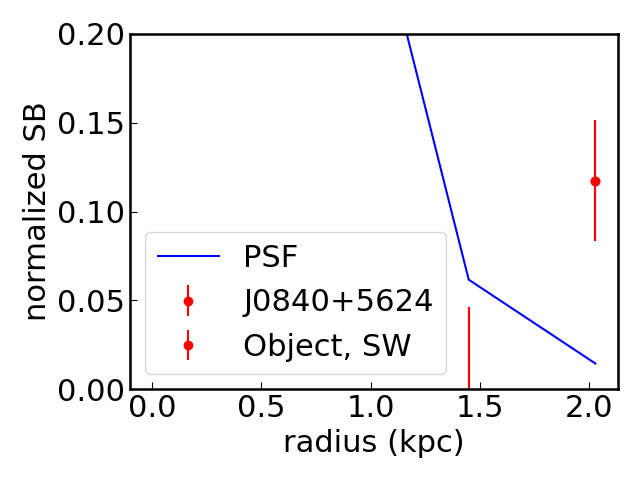

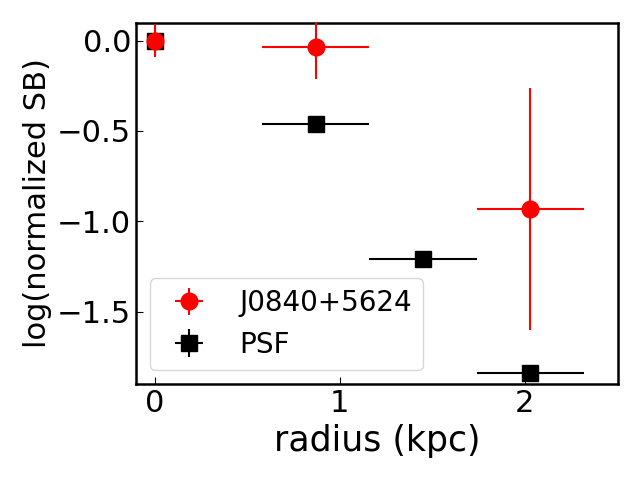

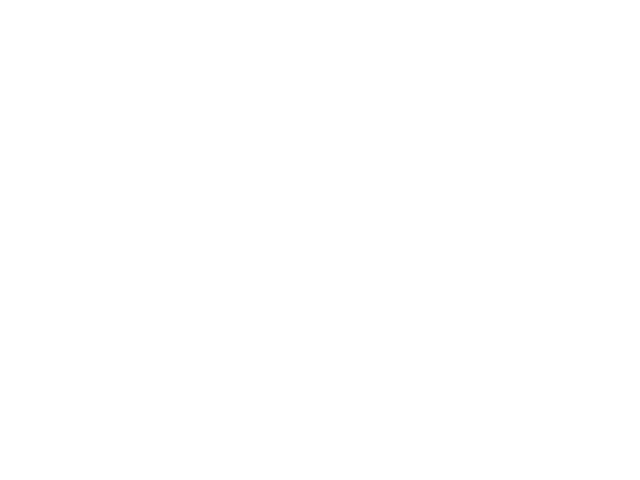

In [43]:
X2,Y2, img2, rflux2,rflux2_err, pk2= X_g395,Y_g395, img_g395, rflux_g395, g395_err, pk_g395

# rflux2 = np.array(10**L5100_all)
# rflux2_err = np.array(10**L5100_all*0.05)

# rflux2 = np.array(L5000_all)
# rflux2_err = np.array(L5000_all*0.05)

radial1 = copy(rflux1[1:nR] - rflux1[0:nR-1])
radial1 = np.append(rflux1[0],radial1)
radial1_err = copy(rflux1_err[1:nR]**2 + rflux1_err[0:nR-1]**2)**0.5
radial1_err = np.append(rflux1_err[0],radial1_err)



radial2 = copy(rflux2[1:nR] - rflux2[0:nR-1])
radial2 = np.append(rflux2[0],radial2)
radial2_err = copy(rflux2_err[1:nR]**2 + rflux2_err[0:nR-1]**2)**0.5
radial2_err = np.append(rflux2_err[0],radial2_err)




plt.figure()
scale = radial1[0]/radial2[0]
# s10 = radial1[0]/R[0]**2
# s20 = radial2[0]/R[0]**2

#ss = 1

ss = np.pi*(R[1:nR]**2-R[0:nR-1]**2)
ss = np.append(np.pi*R[0]**2,ss)


ral1 = radial1/(ss)
ral2 = radial2/(ss)
ral1_err = radial1_err/(ss)
ral2_err = radial2_err/(ss)

# from astropy import units as u
# from astropy.cosmology import FlatLambdaCDM
# cosmo = FlatLambdaCDM(H0=70, Om0=0.3, Tcmb0=2.725)

# #dist0 = cosmo.luminosity_distance(z_cor)
# kpc_arcsec = cosmo.kpc_proper_per_arcmin(z_cor)/60  

plt.figure()
plt.errorbar(R2*kpc_arcsec,ral1/ral1[0],yerr=ral1_err/ral1[0],color='red',label=pdfflag[0:10],fmt='o')
plt.errorbar(R2*kpc_arcsec,ral1/ral1[0],yerr=ral1_err/ral1[0],color='red',label='Object, SW',fmt='o')

#plt.errorbar(R2*kpc_arcsec,ral1/ral1[0],yerr=(ral1**0.5)/ral1[0],color='red',label=pdfflag[0:10])

plt.plot(R2*kpc_arcsec,ral2/ral2[0],'b-',label='PSF')
#plt.ylabel('normalized SB (4-4.5 $\mu$m)',fontsize=22)
#plt.ylabel('surface brightness',fontsize=22)
plt.ylabel('normalized SB',fontsize=22)
#plt.xlabel('radius (arcsec)',fontsize=22)
plt.xlabel('radius (kpc)',fontsize=22)

#plt.axvline(x=0.19/5*4.25/2.,color='k',ls='--',label='diffraction limit')
plt.legend(fontsize=22)
plt.tick_params(labelsize=22)
plt.ylim(0,0.2)
plt.tight_layout()
plt.savefig('compare_psf_nr'+str(int(nR))+pdfflag+'.jpeg',dpi=300)
plt.show()



tmperr = np.log10(ral1/ral1[0]) - np.log10(((ral1-ral1_err)/ral1[0]))
tmperr2 = np.log10((ral1+ral1_err)/ral1[0]) - np.log10(((ral1)/ral1[0]))

fig, ax = plt.subplots()
#plt.errorbar((R2*kpc_arcsec)[:7],(np.log10(ral1/ral1[0]))[:7]\
#             ,yerr=(np.log(10)/(ral1/ral1[0])*ral1_err/ral1[0])[:7],color='red',label=pdfflag[0:10],zorder=5)

#plt.errorbar((R2*kpc_arcsec)[:7],(np.log10(ral1/ral1[0]))[:7]\
#             ,yerr=tmperr2[:7],color='red',label=pdfflag[0:10])
#plt.plot(R2*kpc_arcsec,np.log10(ral2/ral2[0]),'b-',label='PSF',zorder=0)
plt.errorbar((R2*kpc_arcsec),(np.log10(ral1/ral1[0])),xerr=np.array([0,0.05,0.05,0.05])*kpc_arcsec\
             ,yerr=np.abs( (np.log(10)/(ral1/ral1[0])*ral1_err/ral1[0]) ),\
                color='red',label=pdfflag[0:10],zorder=5,fmt='o',ls='None',ms=12)
plt.errorbar((R2*kpc_arcsec),(np.log10(ral2/ral2[0])),xerr=np.array([0,0.05,0.05,0.05])*kpc_arcsec\
             ,yerr=np.abs( (np.log(10)/(ral2/ral2[0])*ral2_err/ral2[0]) ),\
                color='black',label='PSF',zorder=1,fmt='s',ls=None,ms=12)
#plt.ylabel('surface brightness',fontsize=25)
plt.ylabel('log(normalized SB)',fontsize=22)

plt.xlabel('radius (kpc)',fontsize=25)
#plt.axvline(x=0.19/5*4.25/2.,color='k',ls='--',label='diffraction limit')
# plt.text(
#     0.98, 0.98,                 # x, y in axes fraction
#     pdfflag[0:10],
#     transform=ax.transAxes,     # use axes coordinates
#     ha='right', va='top',
#     fontsize=20
# )
plt.legend(fontsize=20,loc='lower left')
plt.tick_params(labelsize=22)

plt.ylim(-1.9,0.1)
plt.xlim(-0.1,2.5)

plt.tight_layout()

#plt.savefig('compare_psf_nr'+str(int(nR))+pdfflag+'_log.jpeg',dpi=300)
plt.savefig('./compare_psf_'+pdfflag+'_log_o3broad.jpeg',dpi=300)

xstar = copy(R2*kpc_arcsec)
ystar = copy(np.log10(ral2/ral2[0]))

plt.show()



In [44]:
# R = (np.arange(nR2)+1)*0.1
# R2 = (np.arange(nR2)+0.5)*0.1
# R2[0] = 0

R_v2 = np.array([0.1, 0.2, 0.4])
R2_v2 = np.array([0.0, 0.15, 0.3])

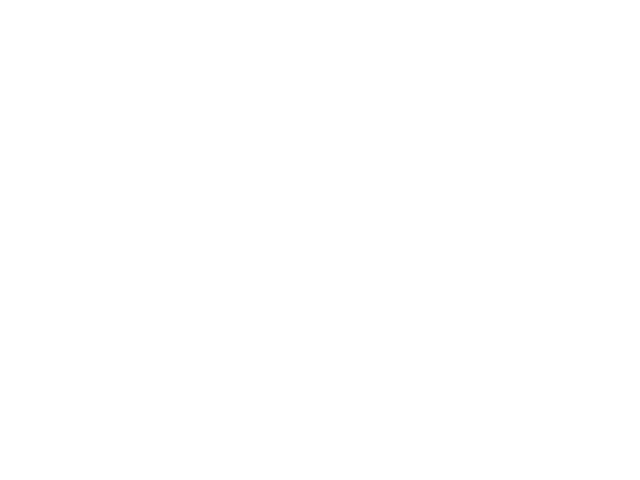

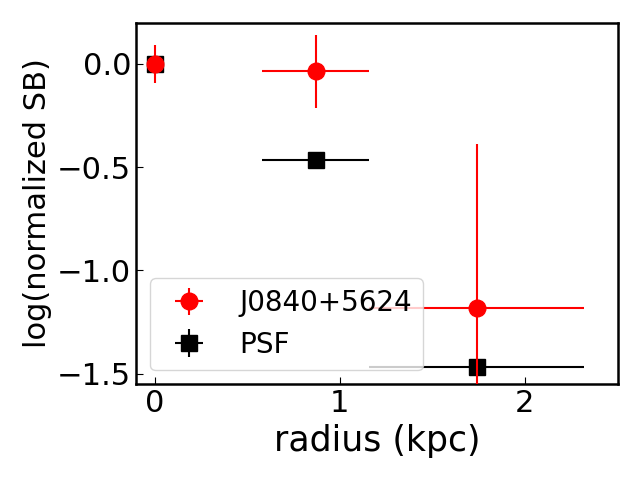

In [45]:
#X2,Y2, img2, rflux2,rflux2_err, pk2= X_g395,Y_g395, img_g395, rflux_g395, g395_err, pk_g395

# rflux2 = np.array(10**L5100_all)
# rflux2_err = np.array(10**L5100_all*0.05)

# rflux2 = np.array(L5000_all)
# rflux2_err = np.array(L5000_all*0.05)

# radial1 = copy(rflux1[1:nR] - rflux1[0:nR-1])
# radial1 = np.append(rflux1[0],radial1)
# radial1_err = copy(rflux1_err[1:nR]**2 + rflux1_err[0:nR-1]**2)**0.5
# radial1_err = np.append(rflux1_err[0],radial1_err)

# bin the 3rd and 4th biun
radial1_v2 = np.append(copy(radial1[0:2]),rflux1[3] - rflux1[1])
radial1_err_v2 = np.append(copy(radial1_err[0:2]),(rflux1_err[3]**2 + rflux1_err[1]**2)**0.5)

radial2_v2 = np.append(copy(radial2[0:2]),rflux2[3] - rflux2[1])
radial2_err_v2 = np.append(copy(radial2_err[0:2]),(rflux2_err[3]**2 + rflux2_err[1]**2)**0.5)

# radial2 = copy(rflux2[1:nR] - rflux2[0:nR-1])
# radial2 = np.append(rflux2[0],radial2)
# radial2_err = copy(rflux2_err[1:nR]**2 + rflux2_err[0:nR-1]**2)**0.5
# radial2_err = np.append(rflux2_err[0],radial2_err)




plt.figure()
scale = radial1[0]/radial2[0]
# s10 = radial1[0]/R[0]**2
# s20 = radial2[0]/R[0]**2

#ss = 1

ss_v2 = np.pi*(R_v2[1:nR-1]**2-R[0:nR-1-1]**2)
ss_v2 = np.append(np.pi*R_v2[0]**2,ss_v2)


ral1_v2 = radial1_v2/(ss_v2)
ral2_v2 = radial2_v2/(ss_v2)
ral1_err_v2 = radial1_err_v2/(ss_v2)
ral2_err_v2 = radial2_err_v2/(ss_v2)

# from astropy import units as u
# from astropy.cosmology import FlatLambdaCDM
# cosmo = FlatLambdaCDM(H0=70, Om0=0.3, Tcmb0=2.725)

# #dist0 = cosmo.luminosity_distance(z_cor)
# kpc_arcsec = cosmo.kpc_proper_per_arcmin(z_cor)/60  

# plt.figure()
# plt.errorbar(R2*kpc_arcsec,ral1/ral1[0],yerr=ral1_err/ral1[0],color='red',label=pdfflag[0:10],fmt='o')
# plt.errorbar(R2*kpc_arcsec,ral1/ral1[0],yerr=ral1_err/ral1[0],color='red',label='Object, SW',fmt='o')

# #plt.errorbar(R2*kpc_arcsec,ral1/ral1[0],yerr=(ral1**0.5)/ral1[0],color='red',label=pdfflag[0:10])

# plt.plot(R2*kpc_arcsec,ral2/ral2[0],'b-',label='PSF')
# #plt.ylabel('normalized SB (4-4.5 $\mu$m)',fontsize=22)
# #plt.ylabel('surface brightness',fontsize=22)
# plt.ylabel('normalized SB',fontsize=22)
# #plt.xlabel('radius (arcsec)',fontsize=22)
# plt.xlabel('radius (kpc)',fontsize=22)

# #plt.axvline(x=0.19/5*4.25/2.,color='k',ls='--',label='diffraction limit')
# plt.legend(fontsize=22)
# plt.tick_params(labelsize=22)
# plt.ylim(0,0.2)
# plt.tight_layout()
# plt.savefig('compare_psf_nr'+str(int(nR))+pdfflag+'.jpeg',dpi=300)
# plt.show()



# tmperr = np.log10(ral1/ral1[0]) - np.log10(((ral1-ral1_err)/ral1[0]))
# tmperr2 = np.log10((ral1+ral1_err)/ral1[0]) - np.log10(((ral1)/ral1[0]))

fig, ax = plt.subplots()
#plt.errorbar((R2*kpc_arcsec)[:7],(np.log10(ral1/ral1[0]))[:7]\
#             ,yerr=(np.log(10)/(ral1/ral1[0])*ral1_err/ral1[0])[:7],color='red',label=pdfflag[0:10],zorder=5)

#plt.errorbar((R2*kpc_arcsec)[:7],(np.log10(ral1/ral1[0]))[:7]\
#             ,yerr=tmperr2[:7],color='red',label=pdfflag[0:10])
#plt.plot(R2*kpc_arcsec,np.log10(ral2/ral2[0]),'b-',label='PSF',zorder=0)
plt.errorbar((R2_v2*kpc_arcsec),(np.log10(ral1_v2/ral1_v2[0]))\
    ,xerr = np.array([0,0.05,0.1])*kpc_arcsec,yerr=np.abs( (np.log(10)/(ral1_v2/ral1_v2[0])*ral1_err_v2/ral1_v2[0]) ),\
                color='red',label=pdfflag[0:10],zorder=5,fmt='o',ls=None,ms=12)
plt.errorbar((R2_v2*kpc_arcsec),(np.log10(ral2_v2/ral2_v2[0])),xerr = np.array([0,0.05,0.1])*kpc_arcsec\
             ,yerr=np.abs( (np.log(10)/(ral2_v2/ral2_v2[0])*ral2_err_v2/ral2_v2[0]) ),\
                color='black',label='PSF',zorder=1,fmt='s',ls=None,ms=12)
#plt.ylabel('surface brightness',fontsize=25)
plt.ylabel('log(normalized SB)',fontsize=22)

plt.xlabel('radius (kpc)',fontsize=25)
#plt.axvline(x=0.19/5*4.25/2.,color='k',ls='--',label='diffraction limit')
# plt.text(
#     0.98, 0.98,                 # x, y in axes fraction
#     pdfflag[0:10],
#     transform=ax.transAxes,     # use axes coordinates
#     ha='right', va='top',
#     fontsize=20
# )
plt.legend(fontsize=20,loc='lower left')
plt.tick_params(labelsize=22)


plt.ylim(-1.9,0.2)
plt.ylim(-1.55,0.2) # for J1141

plt.xlim(-0.1,2.5)

plt.tight_layout()

#plt.savefig('compare_psf_nr'+str(int(nR))+pdfflag+'_log.jpeg',dpi=300)
plt.savefig('./compare_psf_'+pdfflag+'_log_o3broad_binout.jpeg',dpi=300)

xstar = copy(R2*kpc_arcsec)
ystar = copy(np.log10(ral2/ral2[0]))




In [46]:
R_v2, R2_v2

(array([0.1, 0.2, 0.4]), array([0.  , 0.15, 0.3 ]))

[0.03141593 0.25132741 0.21991149]
[0.03141593 0.25132741 0.21991149] [2265.18508392 1174.0100736  1952.92644461]


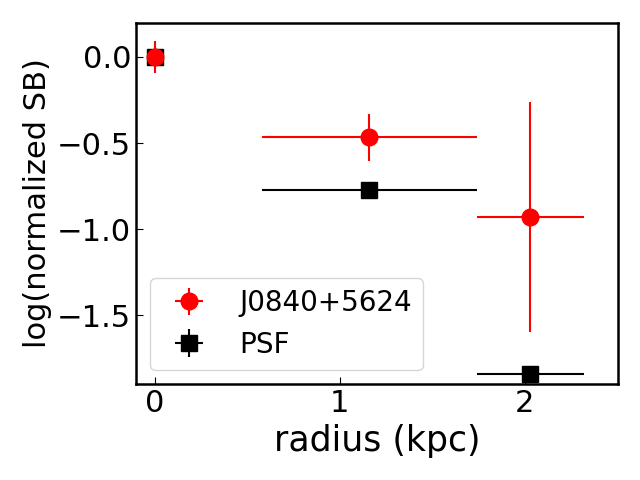

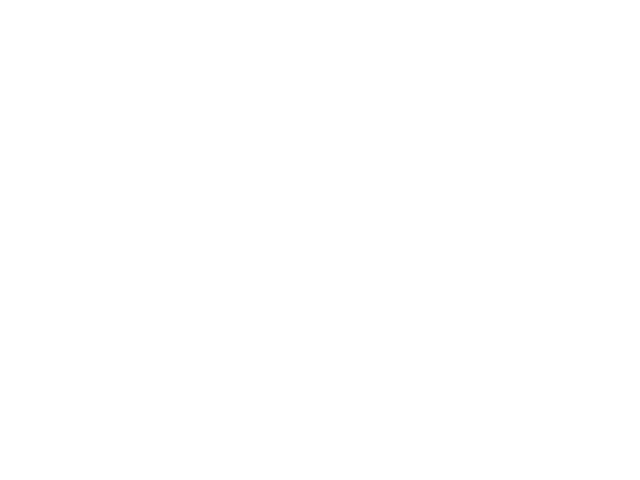

In [47]:
R_v3 = np.array([0.1, 0.3, 0.4])
R2_v3 = np.array([0.0, 0.2, 0.35])

# bin the 2rd and 3th biun
radial1_v3 = np.array([rflux1[0], rflux1[2]-rflux1[0], rflux1[3] - rflux1[2]])
radial1_err_v3 = np.array([rflux1_err[0], (rflux1_err[2]**2 + rflux1_err[0]**2)**0.5, (rflux1_err[3]**2 + rflux1_err[2]**2)**0.5]).flatten()

radial2_v3 = np.array([rflux2[0], rflux2[2]-rflux2[0], rflux2[3] - rflux2[2]])
radial2_err_v3 = np.array([rflux2_err[0], (rflux2_err[2]**2 + rflux2_err[0]**2)**0.5, (rflux2_err[3]**2 + rflux2_err[2]**2)**0.5])

# radial2 = copy(rflux2[1:nR] - rflux2[0:nR-1])
# radial2 = np.append(rflux2[0],radial2)
# radial2_err = copy(rflux2_err[1:nR]**2 + rflux2_err[0:nR-1]**2)**0.5
# radial2_err = np.append(rflux2_err[0],radial2_err)




plt.figure()
# s10 = radial1[0]/R[0]**2
# s20 = radial2[0]/R[0]**2

#ss = 1

# ss_v3 = np.pi*(R_v3[1:nR-1]**2-R[0:nR-1-1]**2)
# ss_v3 = np.append(np.pi*R_v3[0]**2,ss_v3)

ss_v3 = np.array([np.pi*R_v3[0]**2, np.pi*(R_v3[1]**2 - R_v3[0]**2), np.pi*(R_v3[2]**2 - R_v3[1]**2) ]).flatten()

print(ss_v3)

ral1_v3 = radial1_v3/(ss_v3)
ral2_v3 = radial2_v3/(ss_v3)
ral1_err_v3 = radial1_err_v3/(ss_v3)
ral2_err_v3 = radial2_err_v3/(ss_v3)


print(ss_v3, radial1_err_v3/(ss_v3))


# tmperr = np.log10(ral1/ral1[0]) - np.log10(((ral1-ral1_err)/ral1[0]))
# tmperr2 = np.log10((ral1+ral1_err)/ral1[0]) - np.log10(((ral1)/ral1[0]))

fig, ax = plt.subplots()
#plt.errorbar((R2*kpc_arcsec)[:7],(np.log10(ral1/ral1[0]))[:7]\
#             ,yerr=(np.log(10)/(ral1/ral1[0])*ral1_err/ral1[0])[:7],color='red',label=pdfflag[0:10],zorder=5)

#plt.errorbar((R2*kpc_arcsec)[:7],(np.log10(ral1/ral1[0]))[:7]\
#             ,yerr=tmperr2[:7],color='red',label=pdfflag[0:10])
#plt.plot(R2*kpc_arcsec,np.log10(ral2/ral2[0]),'b-',label='PSF',zorder=0)
plt.errorbar((R2_v3*kpc_arcsec.value),(np.log10(ral1_v3/ral1_v3[0]))\
    ,xerr = np.array([0,0.1,0.05])*kpc_arcsec.value,yerr=np.abs( (np.log(10)/(ral1_v3/ral1_v3[0])*ral1_err_v3/ral1_v3[0]) ),\
                color='red',label=pdfflag[0:10],zorder=5,fmt='o',ls=None,ms=12)
plt.errorbar((R2_v3*kpc_arcsec),(np.log10(ral2_v3/ral2_v3[0])),xerr = np.array([0,0.1,0.05])*kpc_arcsec\
             ,yerr=np.abs( (np.log(10)/(ral2_v3/ral2_v3[0])*ral2_err_v3/ral2_v3[0]) ),\
                color='black',label='PSF',zorder=1,fmt='s',ls=None,ms=12)
#plt.ylabel('surface brightness',fontsize=25)
plt.ylabel('log(normalized SB)',fontsize=22)

plt.xlabel('radius (kpc)',fontsize=25)
#plt.axvline(x=0.19/5*4.25/2.,color='k',ls='--',label='diffraction limit')
# plt.text(
#     0.98, 0.98,                 # x, y in axes fraction
#     pdfflag[0:10],
#     transform=ax.transAxes,     # use axes coordinates
#     ha='right', va='top',
#     fontsize=20
# )
plt.legend(fontsize=20,loc='lower left')
plt.tick_params(labelsize=22)

plt.ylim(-1.9,0.2)
plt.xlim(-0.1,2.5)

plt.tight_layout()

#plt.savefig('compare_psf_nr'+str(int(nR))+pdfflag+'_log.jpeg',dpi=300)
plt.savefig('./compare_psf_'+pdfflag+'_log_o3broad_binout_v3.jpeg',dpi=300)

xstar = copy(R2*kpc_arcsec)
ystar = copy(np.log10(ral2/ral2[0]))

plt.show()

         

In [48]:
ss_v3 = np.array([np.pi*R_v3[0]**2, np.pi*(R_v3[1]**2 - R_v3[0]**2), np.pi*(R_v3[2]**2 - R_v3[1]**2) ])
ss_v3

array([0.03141593, 0.25132741, 0.21991149])

In [49]:
ral1_err_v3 , radial1_err_v3, (ss_v3)


(array([2265.18508392, 1174.0100736 , 1952.92644461]),
 array([ 71.16288819, 295.0609138 , 429.470956  ]),
 array([0.03141593, 0.25132741, 0.21991149]))

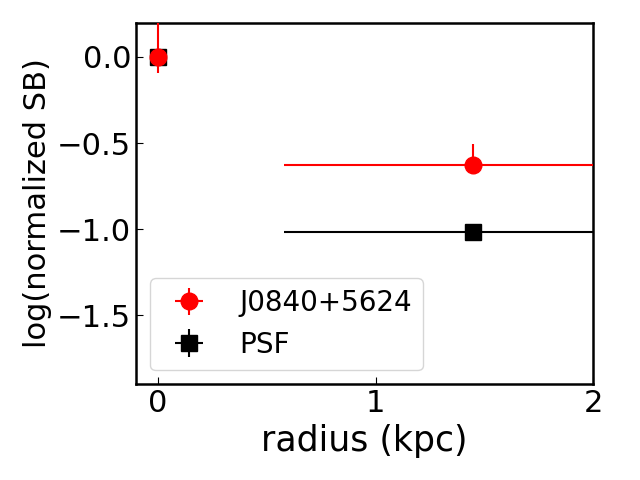

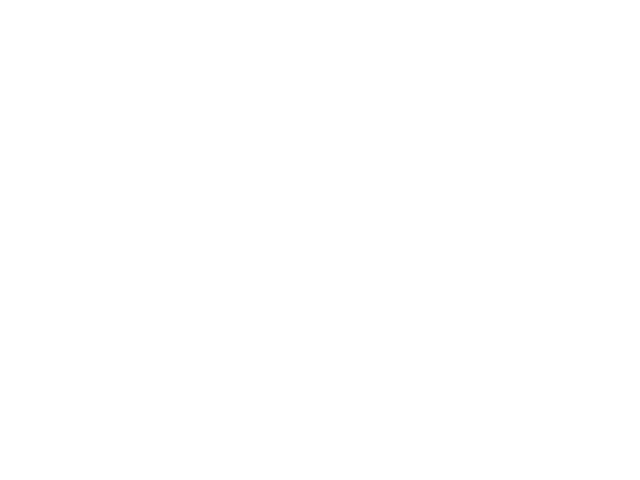

In [50]:
R_v4 = np.array([0.1, 0.4])
R2_v4 = np.array([0.0, 0.25])

# bin the 2rd and 3th 4th biun
radial1_v4 = np.array([rflux1[0], rflux1[3]-rflux1[0]])
radial1_err_v4 = np.array([rflux1_err[0], (rflux1_err[3]**2 + rflux1_err[0]**2)**0.5])

radial2_v4 = np.array([rflux2[0], rflux2[3]-rflux2[0]])
radial2_err_v4 = np.array([rflux2_err[0], (rflux2_err[3]**2 + rflux2_err[0]**2)**0.5])

plt.figure()


ss_v4 = np.array([np.pi*R_v4[0]**2, np.pi*(R_v4[1]**2 - R_v4[0]**2) ])


ral1_v4 = radial1_v4/(ss_v4)
ral2_v4 = radial2_v4/(ss_v4)
ral1_err_v4 = radial1_err_v4/(ss_v4)
ral2_err_v4 = radial2_err_v4/(ss_v4)


# tmperr = np.log10(ral1/ral1[0]) - np.log10(((ral1-ral1_err)/ral1[0]))
# tmperr2 = np.log10((ral1+ral1_err)/ral1[0]) - np.log10(((ral1)/ral1[0]))

fig, ax = plt.subplots()
#plt.errorbar((R2*kpc_arcsec)[:7],(np.log10(ral1/ral1[0]))[:7]\
#             ,yerr=(np.log(10)/(ral1/ral1[0])*ral1_erR2r/ral1[0])[:7],color='red',label=pdfflag[0:10],zorder=5)

#plt.errorbar((R2*kpc_arcsec)[:7],(np.log10(ral1/ral1[0]))[:7]\
#             ,yerr=tmperr2[:7],color='red',label=pdfflag[0:10])
#plt.plot(R2*kpc_arcsec,np.log10(ral2/ral2[0]),'b-',label='PSF',zorder=0)
plt.errorbar((R2_v4*kpc_arcsec.value),(np.log10(ral1_v4/ral1_v4[0]))\
    ,xerr = np.array([0,0.15])*kpc_arcsec.value,yerr=np.abs( (np.log(10)/(ral1_v4/ral1_v4[0])*ral1_err_v4/ral1_v4[0]) ),\
                color='red',label=pdfflag[0:10],zorder=5,fmt='o',ls=None,ms=12)
plt.errorbar((R2_v4*kpc_arcsec),(np.log10(ral2_v4/ral2_v4[0])),xerr = np.array([0,0.15])*kpc_arcsec\
             ,yerr=np.abs( (np.log(10)/(ral2_v4/ral2_v4[0])*ral2_err_v4/ral2_v4[0]) ),\
                color='black',label='PSF',zorder=1,fmt='s',ls=None,ms=12)
#plt.ylabel('surface brightness',fontsize=25)
plt.ylabel('log(normalized SB)',fontsize=22)

plt.xlabel('radius (kpc)',fontsize=25)
#plt.axvline(x=0.19/5*4.25/2.,color='k',ls='--',label='diffraction limit')
# plt.text(
#     0.98, 0.98,                 # x, y in axes fraction
#     pdfflag[0:10],
#     transform=ax.transAxes,     # use axes coordinates
#     ha='right', va='top',
#     fontsize=20
# )
plt.legend(fontsize=20,loc='lower left')
plt.tick_params(labelsize=22)

plt.ylim(-1.9,0.2)
plt.xlim(-0.1,2)

plt.tight_layout()

#plt.savefig('compare_psf_nr'+str(int(nR))+pdfflag+'_log.jpeg',dpi=300)
plt.savefig('./compare_psf_'+pdfflag+'_log_o3broad_binout_v4.jpeg',dpi=300)

xstar = copy(R2*kpc_arcsec)
ystar = copy(np.log10(ral2/ral2[0]))

plt.show()



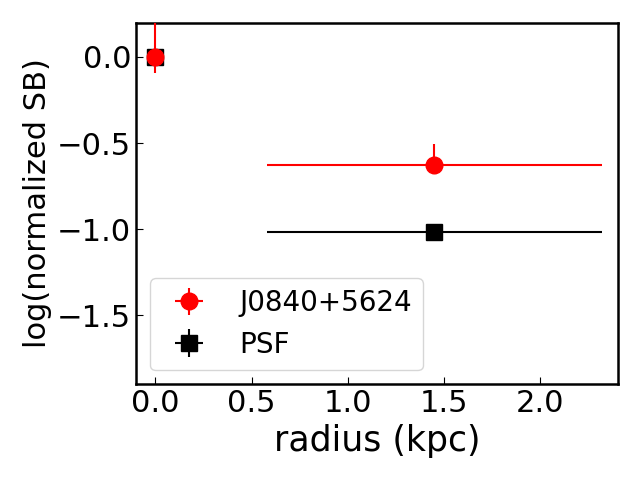

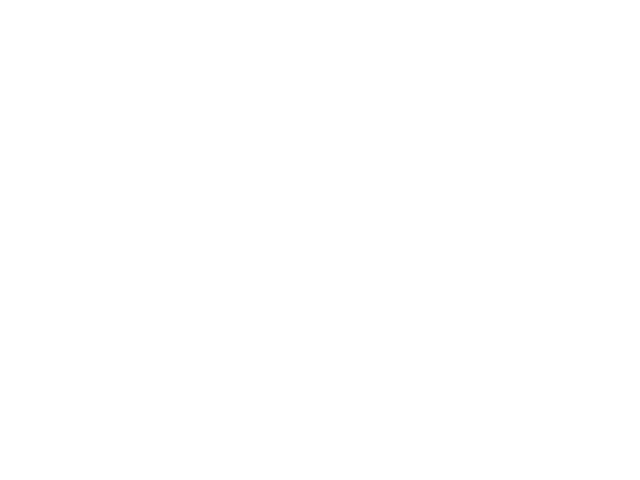

In [51]:
# For J0829

R_v4 = np.array([0.1, 0.4])
R2_v4 = np.array([0.0, 0.25])

# bin the 2rd and 3th 4th biun
radial1_v4 = np.array([rflux1[0], rflux1[3]-rflux1[0]])
radial1_err_v4 = np.array([rflux1_err[0], (rflux1_err[3]**2 + rflux1_err[0]**2)**0.5])

radial2_v4 = np.array([rflux2[0], rflux2[3]-rflux2[0]])
radial2_err_v4 = np.array([rflux2_err[0], (rflux2_err[3]**2 + rflux2_err[0]**2)**0.5])

plt.figure()


ss_v4 = np.array([np.pi*R_v4[0]**2, np.pi*(R_v4[1]**2 - R_v4[0]**2) ])


ral1_v4 = radial1_v4/(ss_v4)
ral2_v4 = radial2_v4/(ss_v4)
ral1_err_v4 = radial1_err_v4/(ss_v4)
ral2_err_v4 = radial2_err_v4/(ss_v4)


# tmperr = np.log10(ral1/ral1[0]) - np.log10(((ral1-ral1_err)/ral1[0]))
# tmperr2 = np.log10((ral1+ral1_err)/ral1[0]) - np.log10(((ral1)/ral1[0]))

fig, ax = plt.subplots()
#plt.errorbar((R2*kpc_arcsec)[:7],(np.log10(ral1/ral1[0]))[:7]\
#             ,yerr=(np.log(10)/(ral1/ral1[0])*ral1_erR2r/ral1[0])[:7],color='red',label=pdfflag[0:10],zorder=5)

#plt.errorbar((R2*kpc_arcsec)[:7],(np.log10(ral1/ral1[0]))[:7]\
#             ,yerr=tmperr2[:7],color='red',label=pdfflag[0:10])
#plt.plot(R2*kpc_arcsec,np.log10(ral2/ral2[0]),'b-',label='PSF',zorder=0)
plt.errorbar((R2_v4*kpc_arcsec.value),(np.log10(ral1_v4/ral1_v4[0]))\
    ,xerr = np.array([0,0.15])*kpc_arcsec.value,yerr=np.abs( (np.log(10)/(ral1_v4/ral1_v4[0])*ral1_err_v4/ral1_v4[0]) ),\
                color='red',label=pdfflag[0:10],zorder=5,fmt='o',ls=None,ms=12)
plt.errorbar((R2_v4*kpc_arcsec),(np.log10(ral2_v4/ral2_v4[0])),xerr = np.array([0,0.15])*kpc_arcsec\
             ,yerr=np.abs( (np.log(10)/(ral2_v4/ral2_v4[0])*ral2_err_v4/ral2_v4[0]) ),\
                color='black',label='PSF',zorder=1,fmt='s',ls=None,ms=12)
#plt.ylabel('surface brightness',fontsize=25)
plt.ylabel('log(normalized SB)',fontsize=22)

plt.xlabel('radius (kpc)',fontsize=25)
#plt.axvline(x=0.19/5*4.25/2.,color='k',ls='--',label='diffraction limit')
# plt.text(
#     0.98, 0.98,                 # x, y in axes fraction
#     pdfflag[0:10],
#     transform=ax.transAxes,     # use axes coordinates
#     ha='right', va='top',
#     fontsize=20
# )
plt.legend(fontsize=20,loc='lower left')
plt.tick_params(labelsize=22)

plt.ylim(-1.9,0.2)
plt.xlim(-0.1,2.4)

plt.tight_layout()

#plt.savefig('compare_psf_nr'+str(int(nR))+pdfflag+'_log.jpeg',dpi=300)
plt.savefig('./compare_psf_'+pdfflag+'_log_o3broad_binout_v4bb.jpeg',dpi=300)

xstar = copy(R2*kpc_arcsec)
ystar = copy(np.log10(ral2/ral2[0]))

plt.show()



In [52]:
np.abs( (np.log(10)/(ral1_v4/ral1_v4[0])*ral1_err_v4/ral1_v4[0]) )

array([[0.09113016, 0.0256658 ],
       [0.41989276, 0.11825816]])

In [53]:
ss_v4/np.pi

array([0.01, 0.15])

In [54]:
ss_v3 = np.array([np.pi*R_v3[0]**2, np.pi*(R_v3[1]**2 - R_v3[0]**2), np.pi*(R_v3[2]**2 - R_v3[1]**2) ])


In [55]:
ss_v3

array([0.03141593, 0.25132741, 0.21991149])

In [56]:
# X2,Y2, img2, rflux2,rflux2_err, pk2= X_g395,Y_g395, img_g395, rflux_g395, g395_err, pk_g395

# # rflux2 = np.array(10**L5100_all)
# # rflux2_err = np.array(10**L5100_all*0.05)

# # rflux2 = np.array(L5000_all)
# # rflux2_err = np.array(L5000_all*0.05)



# radial2 = copy(rflux2[1:nR] - rflux2[0:nR-1])
# radial2 = np.append(rflux2[0],radial2)
# radial2_err = copy(rflux2_err[1:nR]**2 + rflux2_err[0:nR-1]**2)**0.5
# radial2_err = np.append(rflux2_err[0],radial2_err)




# plt.figure()
# scale = radial1[0]/radial2[0]
# # s10 = radial1[0]/R[0]**2
# # s20 = radial2[0]/R[0]**2

# #ss = 1

# ss = np.pi*(R[1:nR]**2-R[0:nR-1]**2)
# ss = np.append(np.pi*R[0]**2,ss)


# ral1 = radial1/(ss)
# ral2 = radial2/(ss)
# ral1_err = radial1_err/(ss)
# ral2_err = radial2_err/(ss)

# # from astropy import units as u
# # from astropy.cosmology import FlatLambdaCDM
# # cosmo = FlatLambdaCDM(H0=70, Om0=0.3, Tcmb0=2.725)

# # #dist0 = cosmo.luminosity_distance(z_cor)
# # kpc_arcsec = cosmo.kpc_proper_per_arcmin(z_cor)/60  

# plt.figure()
# plt.errorbar(R2*kpc_arcsec,ral1/ral1[0],yerr=ral1_err/ral1[0],color='red',label=pdfflag[0:10],fmt='o')
# plt.errorbar(R2*kpc_arcsec,ral1/ral1[0],yerr=ral1_err/ral1[0],color='red',label='Object, SW',fmt='o')

# #plt.errorbar(R2*kpc_arcsec,ral1/ral1[0],yerr=(ral1**0.5)/ral1[0],color='red',label=pdfflag[0:10])

# plt.plot(R2*kpc_arcsec,ral2/ral2[0],'b-',label='PSF')
# #plt.ylabel('normalized SB (4-4.5 $\mu$m)',fontsize=22)
# #plt.ylabel('surface brightness',fontsize=22)
# plt.ylabel('normalized SB',fontsize=22)
# #plt.xlabel('radius (arcsec)',fontsize=22)
# plt.xlabel('radius (kpc)',fontsize=22)

# #plt.axvline(x=0.19/5*4.25/2.,color='k',ls='--',label='diffraction limit')
# plt.legend(fontsize=22)
# plt.tick_params(labelsize=22)
# plt.ylim(0,0.2)
# plt.tight_layout()
# plt.savefig('compare_psf_nr'+str(int(nR))+pdfflag+'.jpeg',dpi=300)
# plt.show()



# tmperr = np.log10(ral1/ral1[0]) - np.log10(((ral1-ral1_err)/ral1[0]))
# tmperr2 = np.log10((ral1+ral1_err)/ral1[0]) - np.log10(((ral1)/ral1[0]))

# fig, ax = plt.subplots()
# #plt.errorbar((R2*kpc_arcsec)[:7],(np.log10(ral1/ral1[0]))[:7]\
# #             ,yerr=(np.log(10)/(ral1/ral1[0])*ral1_err/ral1[0])[:7],color='red',label=pdfflag[0:10],zorder=5)

# #plt.errorbar((R2*kpc_arcsec)[:7],(np.log10(ral1/ral1[0]))[:7]\
# #             ,yerr=tmperr2[:7],color='red',label=pdfflag[0:10])
# #plt.plot(R2*kpc_arcsec,np.log10(ral2/ral2[0]),'b-',label='PSF',zorder=0)
# plt.errorbar((R2*kpc_arcsec)[:4],(np.log10(ral1/ral1[0]))[:4]\
#              ,yerr=np.abs( (np.log(10)/(ral1/ral1[0])*ral1_err/ral1[0])[:4] ),\
#                 color='red',label=pdfflag[0:10],zorder=5,fmt='o',ls='-')
# plt.errorbar((R2*kpc_arcsec)[:8],(np.log10(ral2/ral2[0]))[:8]\
#              ,yerr=np.abs( (np.log(10)/(ral2/ral2[0])*ral2_err/ral2[0])[:8] ),\
#                 color='black',label='PSF',zorder=1,fmt='s',ls='-',ms=3)
# #plt.ylabel('surface brightness',fontsize=25)
# plt.ylabel('log(normalized SB)',fontsize=22)

# plt.xlabel('radius (kpc)',fontsize=25)
# #plt.axvline(x=0.19/5*4.25/2.,color='k',ls='--',label='diffraction limit')
# plt.text(
#     0.98, 0.98,                 # x, y in axes fraction
#     pdfflag[0:10],
#     transform=ax.transAxes,     # use axes coordinates
#     ha='right', va='top',
#     fontsize=20
# )
# plt.legend(fontsize=20,loc='lower left')
# plt.tick_params(labelsize=22)

# plt.ylim(-2,0)
# plt.xlim(0,2)

# plt.tight_layout()

# #plt.savefig('compare_psf_nr'+str(int(nR))+pdfflag+'_log.jpeg',dpi=300)
# plt.savefig('./compare_psf_'+pdfflag+'_log_o3broad.jpeg',dpi=300)

# xstar = copy(R2*kpc_arcsec)
# ystar = copy(np.log10(ral2/ral2[0]))

# plt.show()



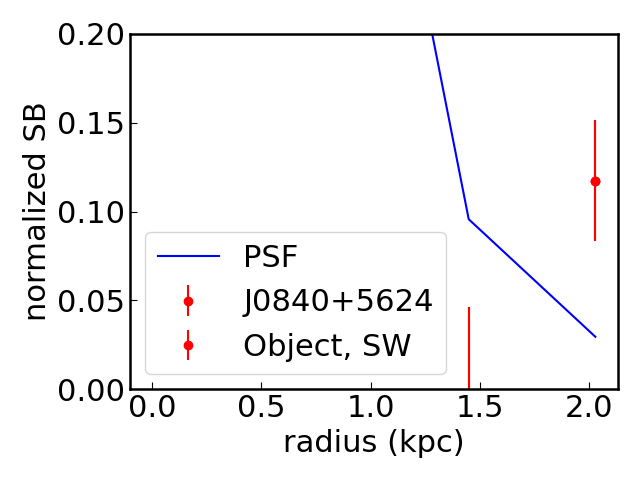

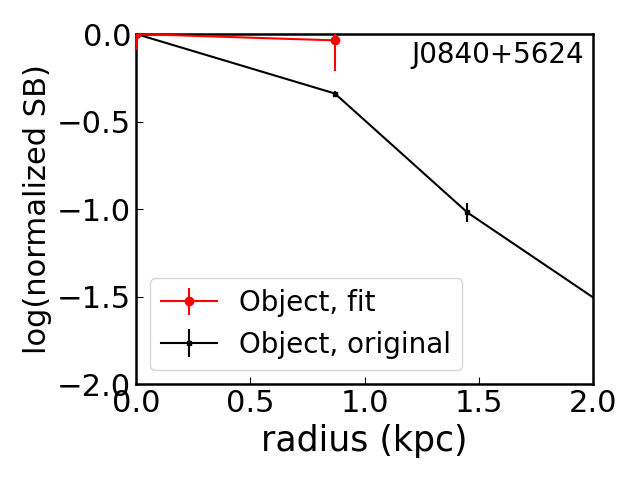

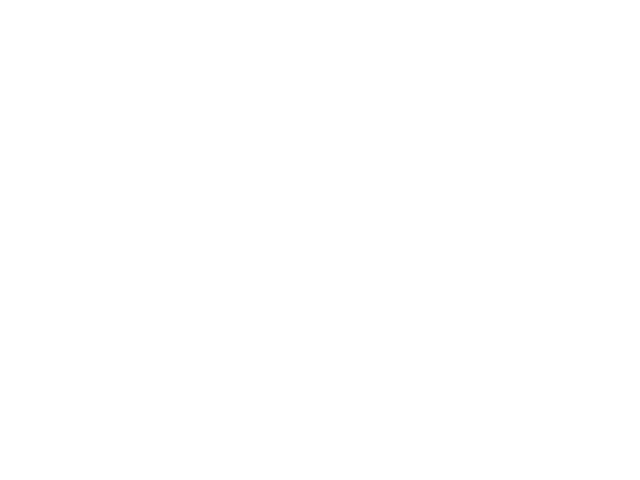

In [57]:
X2,Y2, img2, rflux2, rflux2_err, pk2 = X3,Y3, img3, rflux3,rflux_err3, pk3

radial2 = copy(rflux2[1:nR] - rflux2[0:nR-1])
radial2 = np.append(rflux2[0],radial2)

radial2_err = copy(rflux2_err[1:nR]**2 + rflux2_err[0:nR-1]**2)**0.5
radial2_err = np.append(rflux2_err[0],radial2_err)



plt.figure()
scale = radial1[0]/radial2[0]
# s10 = radial1[0]/R[0]**2
# s20 = radial2[0]/R[0]**2

#ss = 1

ss = np.pi*(R[1:nR]**2-R[0:nR-1]**2)
ss = np.append(np.pi*R[0]**2,ss)


ral1 = radial1/(ss)
ral2 = radial2/(ss)
ral1_err = radial1_err/(ss)
ral2_err = radial2_err/(ss)

# from astropy import units as u
# from astropy.cosmology import FlatLambdaCDM
# cosmo = FlatLambdaCDM(H0=70, Om0=0.3, Tcmb0=2.725)

# #dist0 = cosmo.luminosity_distance(z_sys)
# kpc_arcsec = cosmo.kpc_proper_per_arcmin(z_sys)/60  

plt.figure()
plt.errorbar(R2*kpc_arcsec,ral1/ral1[0],yerr=ral1_err/ral1[0],color='red',label=pdfflag[0:10],fmt='o')
plt.errorbar(R2*kpc_arcsec,ral1/ral1[0],yerr=ral1_err/ral1[0],color='red',label='Object, SW',fmt='o')

#plt.errorbar(R2*kpc_arcsec,ral1/ral1[0],yerr=(ral1**0.5)/ral1[0],color='red',label=pdfflag[0:10])

plt.plot(R2*kpc_arcsec,ral2/ral2[0],'b-',label='PSF')
#plt.ylabel('normalized SB (4-4.5 $\mu$m)',fontsize=22)
#plt.ylabel('surface brightness',fontsize=22)
plt.ylabel('normalized SB',fontsize=22)
#plt.xlabel('radius (arcsec)',fontsize=22)
plt.xlabel('radius (kpc)',fontsize=22)

#plt.axvline(x=0.19/5*4.25/2.,color='k',ls='--',label='diffraction limit')
plt.legend(fontsize=22)
plt.tick_params(labelsize=22)
plt.ylim(0,0.2)
plt.tight_layout()
plt.savefig('compare_psf_nr'+str(int(nR))+pdfflag+'.jpeg',dpi=300)
plt.show()



tmperr = np.log10(ral1/ral1[0]) - np.log10(((ral1-ral1_err)/ral1[0]))
tmperr2 = np.log10((ral1+ral1_err)/ral1[0]) - np.log10(((ral1)/ral1[0]))

fig, ax = plt.subplots()
#plt.errorbar((R2*kpc_arcsec)[:7],(np.log10(ral1/ral1[0]))[:7]\
#             ,yerr=(np.log(10)/(ral1/ral1[0])*ral1_err/ral1[0])[:7],color='red',label=pdfflag[0:10],zorder=5)

#plt.errorbar((R2*kpc_arcsec)[:7],(np.log10(ral1/ral1[0]))[:7]\
#             ,yerr=tmperr2[:7],color='red',label=pdfflag[0:10])
#plt.plot(R2*kpc_arcsec,np.log10(ral2/ral2[0]),'b-',label='PSF',zorder=0)
plt.errorbar((R2*kpc_arcsec)[:4],(np.log10(ral1/ral1[0]))[:4]\
             ,yerr=np.abs( (np.log(10)/(ral1/ral1[0])*ral1_err/ral1[0])[:4] ),\
                color='red',label='Object, fit',zorder=5,fmt='o',ls='-')
plt.errorbar((R2*kpc_arcsec)[:8],(np.log10(ral2/ral2[0]))[:8]\
             ,yerr=np.abs( (np.log(10)/(ral2/ral2[0])*ral2_err/ral2[0])[:8] ),\
                color='black',label='Object, original',zorder=1,fmt='s',ls='-',ms=3)
#plt.ylabel('surface brightness',fontsize=25)
plt.ylabel('log(normalized SB)',fontsize=22)

plt.xlabel('radius (kpc)',fontsize=25)
#plt.axvline(x=0.19/5*4.25/2.,color='k',ls='--',label='diffraction limit')
plt.text(
    0.98, 0.98,                 # x, y in axes fraction
    pdfflag[0:10],
    transform=ax.transAxes,     # use axes coordinates
    ha='right', va='top',
    fontsize=20
)
plt.legend(fontsize=20,loc='lower left')
plt.tick_params(labelsize=22)

plt.ylim(-2,0)
plt.xlim(0,2)

plt.tight_layout()

#plt.savefig('compare_psf_nr'+str(int(nR))+pdfflag+'_log.jpeg',dpi=300)
plt.savefig('./compare_psf_'+pdfflag+'_log_o3broad_o3continuum.jpeg',dpi=300)

xstar = copy(R2*kpc_arcsec)
ystar = copy(np.log10(ral2/ral2[0]))

plt.show()



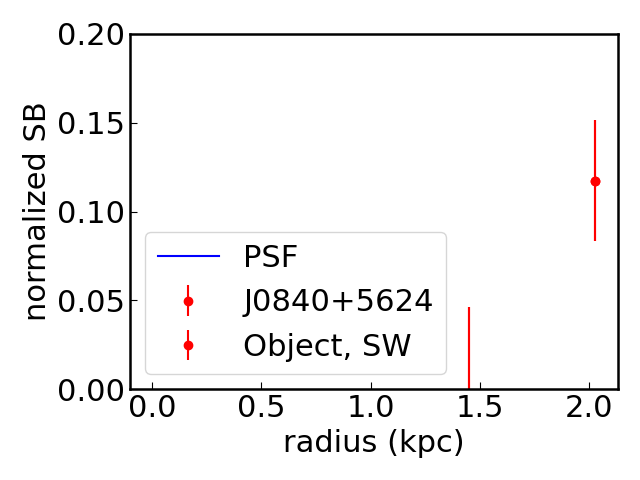

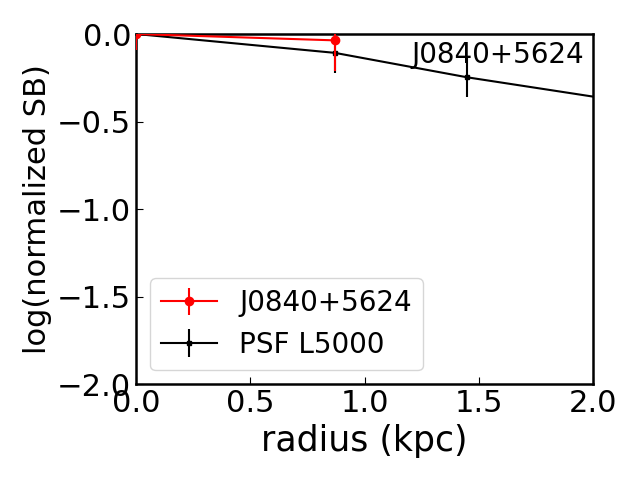

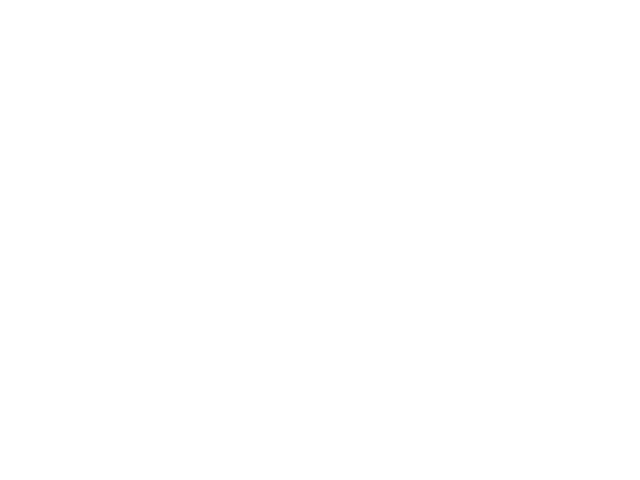

In [58]:
rflux2 = np.array(L5000_all)
rflux2_err = np.array(L5000_all*0.05)

# radial1 = copy(rflux1[1:nR] - rflux1[0:nR-1])
# radial1 = np.append(rflux1[0],radial1)
# radial1_err = copy(rflux1_err[1:nR]**2 + rflux1_err[0:nR-1]**2)**0.5
# radial1_err = np.append(rflux1_err[0],radial1_err)

radial2 = rflux2
radial2_err = rflux2_err



plt.figure()
scale = radial1[0]/radial2[0]
# s10 = radial1[0]/R[0]**2
# s20 = radial2[0]/R[0]**2

#ss = 1

ss = np.pi*(R[1:nR]**2-R[0:nR-1]**2)
ss = np.append(np.pi*R[0]**2,ss)


ral1 = radial1/(ss)
ral2 = radial2/(ss)
ral1_err = radial1_err/(ss)
ral2_err = radial2_err/(ss)

# from astropy import units as u
# from astropy.cosmology import FlatLambdaCDM
# cosmo = FlatLambdaCDM(H0=70, Om0=0.3, Tcmb0=2.725)

# #dist0 = cosmo.luminosity_distance(z_sys)
# kpc_arcsec = cosmo.kpc_proper_per_arcmin(z_sys)/60  

plt.figure()
plt.errorbar(R2*kpc_arcsec,ral1/ral1[0],yerr=ral1_err/ral1[0],color='red',label=pdfflag[0:10],fmt='o')
plt.errorbar(R2*kpc_arcsec,ral1/ral1[0],yerr=ral1_err/ral1[0],color='red',label='Object, SW',fmt='o')

#plt.errorbar(R2*kpc_arcsec,ral1/ral1[0],yerr=(ral1**0.5)/ral1[0],color='red',label=pdfflag[0:10])

plt.plot(R2*kpc_arcsec,ral2/ral2[0],'b-',label='PSF')
#plt.ylabel('normalized SB (4-4.5 $\mu$m)',fontsize=22)
#plt.ylabel('surface brightness',fontsize=22)
plt.ylabel('normalized SB',fontsize=22)
#plt.xlabel('radius (arcsec)',fontsize=22)
plt.xlabel('radius (kpc)',fontsize=22)

#plt.axvline(x=0.19/5*4.25/2.,color='k',ls='--',label='diffraction limit')
plt.legend(fontsize=22)
plt.tick_params(labelsize=22)
plt.ylim(0,0.2)
plt.tight_layout()
plt.savefig('compare_psf_nr'+str(int(nR))+pdfflag+'.jpeg',dpi=300)
plt.show()



tmperr = np.log10(ral1/ral1[0]) - np.log10(((ral1-ral1_err)/ral1[0]))
tmperr2 = np.log10((ral1+ral1_err)/ral1[0]) - np.log10(((ral1)/ral1[0]))

fig, ax = plt.subplots()
#plt.errorbar((R2*kpc_arcsec)[:7],(np.log10(ral1/ral1[0]))[:7]\
#             ,yerr=(np.log(10)/(ral1/ral1[0])*ral1_err/ral1[0])[:7],color='red',label=pdfflag[0:10],zorder=5)

#plt.errorbar((R2*kpc_arcsec)[:7],(np.log10(ral1/ral1[0]))[:7]\
#             ,yerr=tmperr2[:7],color='red',label=pdfflag[0:10])
#plt.plot(R2*kpc_arcsec,np.log10(ral2/ral2[0]),'b-',label='PSF',zorder=0)
plt.errorbar((R2*kpc_arcsec)[:4],(np.log10(ral1/ral1[0]))[:4]\
             ,yerr=np.abs( (np.log(10)/(ral1/ral1[0])*ral1_err/ral1[0])[:4] ),\
                color='red',label=pdfflag[0:10],zorder=5,fmt='o',ls='-')
plt.errorbar((R2*kpc_arcsec)[:8],(np.log10(ral2/ral2[0]))[:8]\
             ,yerr=np.abs( (np.log(10)/(ral2/ral2[0])*ral2_err/ral2[0])[:8] ),\
                color='black',label='PSF L5000',zorder=1,fmt='s',ls='-',ms=3)
#plt.ylabel('surface brightness',fontsize=25)
plt.ylabel('log(normalized SB)',fontsize=22)

plt.xlabel('radius (kpc)',fontsize=25)
#plt.axvline(x=0.19/5*4.25/2.,color='k',ls='--',label='diffraction limit')
plt.text(
    0.98, 0.98,                 # x, y in axes fraction
    pdfflag[0:10],
    transform=ax.transAxes,     # use axes coordinates
    ha='right', va='top',
    fontsize=20
)
plt.legend(fontsize=20,loc='lower left')
plt.tick_params(labelsize=22)

plt.ylim(-2,0)
plt.xlim(0,2)

plt.tight_layout()

#plt.savefig('compare_psf_nr'+str(int(nR))+pdfflag+'_log.jpeg',dpi=300)
plt.savefig('./compare_psf_'+pdfflag+'_log_o3broad_L5000.jpeg',dpi=300)

xstar = copy(R2*kpc_arcsec)
ystar = copy(np.log10(ral2/ral2[0]))

plt.show()

